## ベース

In [ ]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

cols = [0] + list(range(2,26))
denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                 index_col=0,   
                 parse_dates=True) 
#denki.index = denki.index.strftime('%Y-%m')
denki = denki.resample('1ME').sum()
denki.index = denki.index.to_period('M')

denki

,0:00～1:00,1:00～2:00,2:00～3:00,3:00～4:00,4:00～5:00,5:00～6:00,6:00～7:00,7:00～8:00,8:00～9:00,9:00～10:00,...,14:00～15:00,15:00～16:00,16:00～17:00,17:00～18:00,18:00～19:00,19:00～20:00,20:00～21:00,21:00～22:00,22:00～23:00,23:00～24:00
date,,,,,,,,,,,,,,,,,,,,,
2023-10,8.0,6.9,23.6,108.7,113.9,45.6,8.0,6.2,6.1,11.1,...,6.7,6.3,7.0,8.0,9.9,9.9,8.5,8.4,8.9,8.6
2023-11,9.5,8.9,35.1,107.9,137.4,83.7,6.7,6.0,7.2,8.9,...,8.1,7.7,7.7,9.6,9.3,8.9,10.4,9.8,9.8,10.1
2023-12,31.1,50.3,96.3,131.3,123.3,43.6,7.6,7.1,9.0,11.0,...,9.7,10.1,10.9,13.4,13.7,16.6,16.7,21.8,20.6,25.4
2024-01,44.6,85.0,136.9,153.2,146.6,44.8,22.4,23.3,15.2,14.5,...,18.1,18.4,19.4,23.7,24.2,28.2,28.5,33.1,33.8,34.0
2024-02,28.1,58.9,114.8,134.2,128.6,48.1,8.1,11.0,8.3,8.4,...,20.4,18.7,17.0,16.1,17.8,20.8,18.7,16.5,21.0,22.1
2024-03,27.4,46.4,100.9,133.8,122.8,52.1,16.6,19.6,13.9,16.2,...,11.5,12.1,12.0,13.0,15.1,16.1,16.8,16.9,17.7,18.7
2024-04,12.9,27.9,62.6,134.1,138.1,79.4,9.4,7.7,7.1,9.2,...,11.0,9.9,10.7,11.0,12.8,12.8,11.7,11.6,11.8,11.5
2024-05,12.1,16.3,28.0,72.3,130.7,106.6,11.4,7.8,8.1,9.0,...,9.8,9.4,9.1,10.1,10.2,10.4,11.0,11.9,11.2,14.6
2024-06,9.7,13.2,27.9,97.7,127.3,60.1,10.2,8.2,9.8,11.7,...,15.6,13.7,14.3,14.1,12.5,12.1,12.6,12.8,13.3,12.3


In [2]:
from pandas import Series, DataFrame

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn; seaborn.set()
import pandas as pd
import numpy as np
from IPython.display import display_html
seaborn.set(font='IPAexGothic')

# 我が家の節電計画

## 使用データ
[電力会社のWebページ](https://katene.chuden.jp/)から、直近3年分（2023年10月〜2026年9月途中）の毎日の1時間毎の電気使用量（Kwh）をCSVで取得した。

In [5]:
cols = [0] + list(range(2,26))
denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                 index_col=0,   
                 parse_dates=True) 

denki

,0:00～1:00,1:00～2:00,2:00～3:00,3:00～4:00,4:00～5:00,5:00～6:00,6:00～7:00,7:00～8:00,8:00～9:00,9:00～10:00,...,14:00～15:00,15:00～16:00,16:00～17:00,17:00～18:00,18:00～19:00,19:00～20:00,20:00～21:00,21:00～22:00,22:00～23:00,23:00～24:00
date,,,,,,,,,,,,,,,,,,,,,
2023-10-05,0.2,0.4,0.9,4.4,4.5,0.4,0.2,0.2,0.2,0.5,...,0.5,0.3,0.4,0.3,0.7,0.4,0.3,0.3,0.3,0.3
2023-10-06,0.2,0.1,0.2,4.6,5.2,1.0,0.2,0.2,0.3,0.5,...,0.3,0.2,0.2,0.5,0.4,0.3,0.3,0.4,0.4,0.4
2023-10-07,0.8,0.8,3.9,4.6,4.5,3.7,0.3,0.3,0.2,0.5,...,0.3,0.4,0.4,0.4,0.5,0.8,0.3,0.3,0.4,0.3
2023-10-08,0.3,0.2,0.3,4.7,4.4,0.2,0.2,0.3,0.2,0.5,...,0.3,0.2,0.2,0.4,0.5,0.3,0.3,0.2,0.3,0.5
2023-10-09,0.4,0.4,0.4,3.5,5.1,2.7,0.4,0.3,0.4,1.1,...,0.2,0.2,0.2,0.1,0.2,0.4,0.4,0.3,0.4,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-01,0.4,0.5,0.4,3.7,2.7,0.4,0.5,0.4,0.5,0.6,...,0.5,0.8,0.2,0.2,0.7,1.2,0.9,0.8,0.5,0.4
2026-09-02,0.4,0.5,1.5,4.8,4.7,4.8,1.0,0.4,0.5,0.5,...,0.7,0.5,0.5,1.0,0.5,0.4,0.7,0.5,0.6,0.6
2026-09-03,0.4,0.5,1.3,4.8,4.7,3.8,0.6,0.4,0.4,0.4,...,0.8,0.8,0.7,0.9,0.7,0.6,0.5,0.5,0.6,0.4


# 3年分 / 月毎　　電気使用量（Kwh)

我が家は、オール電化であるため、深夜帯に使用電力が集中しているね。
夜間帯に集中しているのは、オール電化専用のプランは3時間帯別に料金が設定されているよ。  

最も料金が安いのが  
1.ナイトタイム　となっているんだね。  

この間に、電気温水器、食洗機、洗濯乾燥などの使用を集中させているよ。

1. ナイトタイム　｜　23:00-7:00　　　　　　　｜　16.11円　（〜24年03月　16.22円）
2. ホームタイム　｜　7:00-9:00 , 17:00-23:00　｜　26.00円　（〜24年03月　26.15円）
3. デイタイム　　｜　9:00-17:00　　　　　　　｜　34.06円　（〜24年03月　34.21円）

[中部電力［電灯契約］Eライフプラン（3時間帯別電灯）](https://miraiz.chuden.co.jp/home/electric/menu/ancillary/elife/)

寝ている間に、毎日同様に稼働するものではなく  
日常の営みでの変化も見てみよう。

おおよそ  
起床時間が6時前後  
睡眠時間が24時前後  
  
6:00~24:00までを活動時間として、起きている時間帯の電気の使用状況を見てみようね。　　

Text(0.5, 1.0, '我が家の電気使用量 24時間・23.10-26.08/月毎（Kwh）')

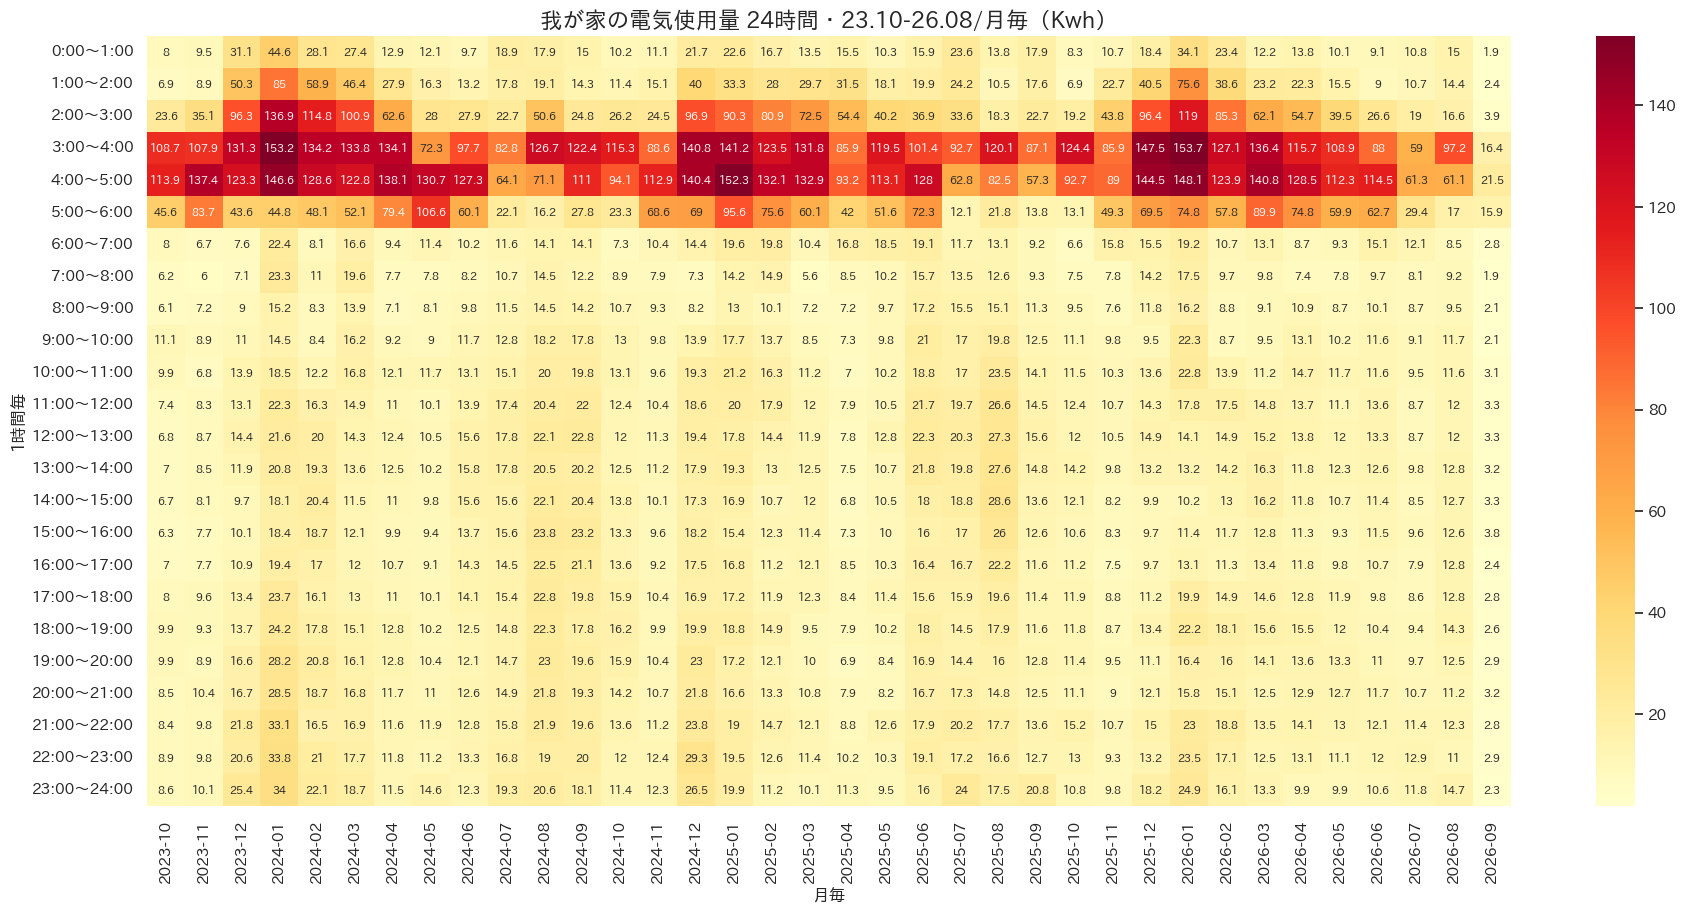

In [73]:
cols = [0] + list(range(2,26))
denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                 index_col=0,   
                 parse_dates=True) 
denki = denki.resample('1ME').sum()
denki.index = denki.index.strftime('%Y-%m')

denki_3y1 = denki.T
denki_3y1

plt.figure(figsize=(22, 10))
seaborn.heatmap(denki_3y1, annot=True, fmt='g',  cmap='YlOrRd',  annot_kws={'size':8})
plt.ylabel('1時間毎')
plt.xlabel('月毎')
plt.title('我が家の電気使用量 24時間・23.10-26.08/月毎（Kwh）', fontsize=16)

Text(0.5, 1.0, '我が家の電気料金 24時間・23.10-26.08/月毎（¥）')

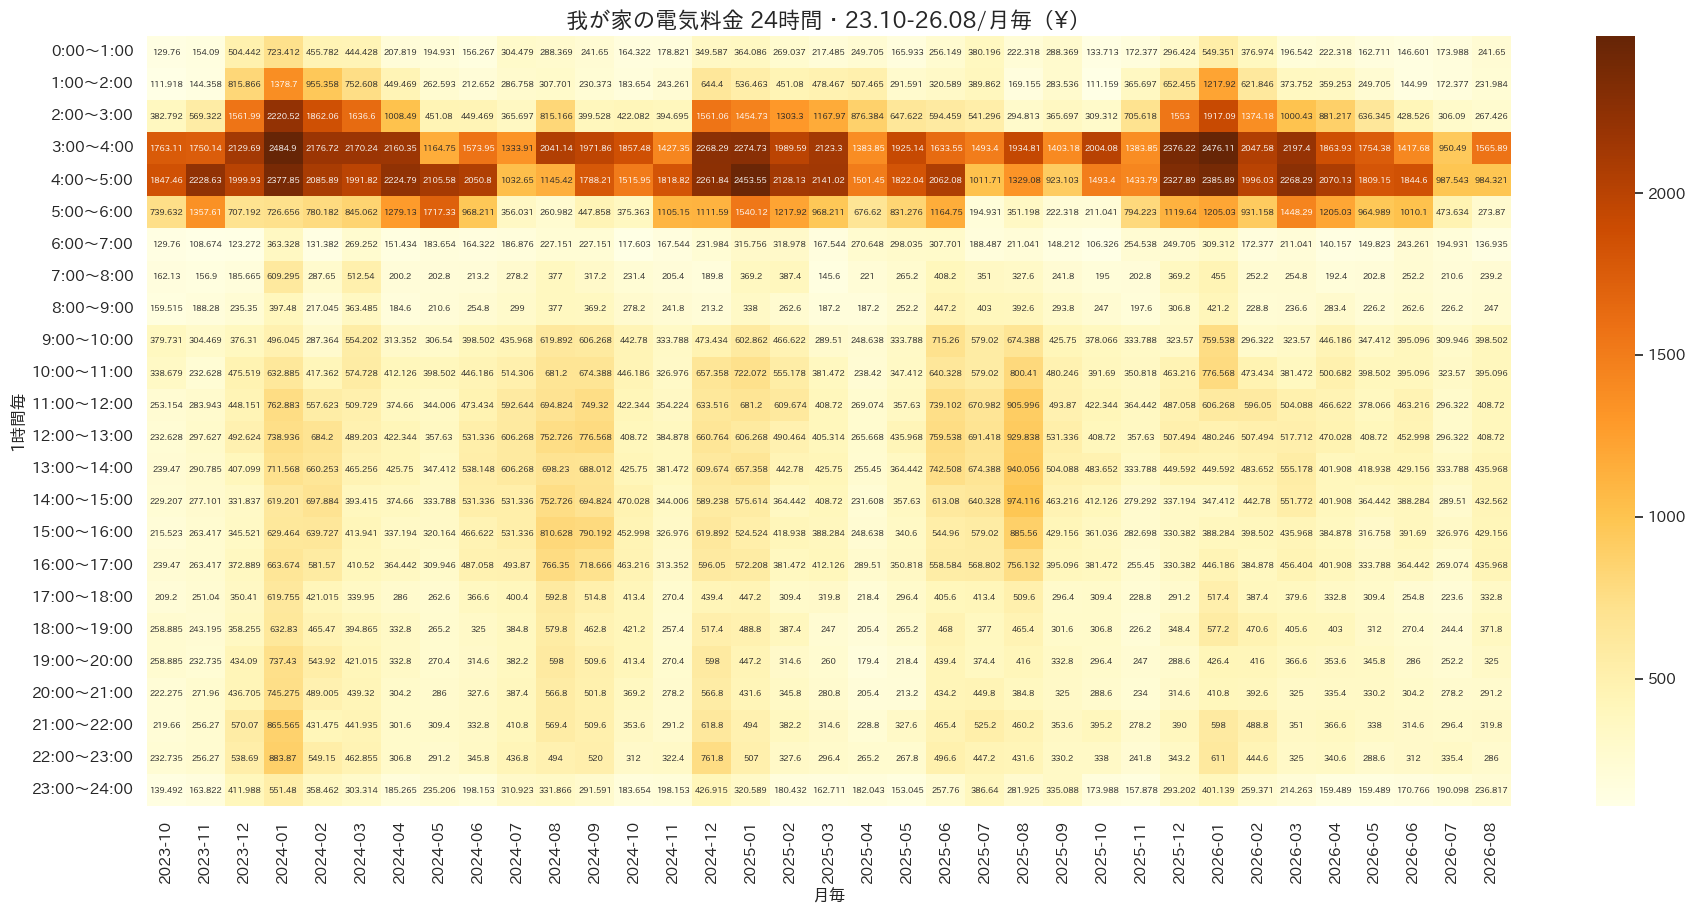

In [72]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2

denki = denki.drop(index=['2026-09'])

denki_3y3 = denki.T
denki_3y3

plt.figure(figsize=(22, 10))
seaborn.heatmap(denki_3y3, annot=True, fmt='g',  cmap='YlOrBr',  annot_kws={'size':6})
plt.ylabel('1時間毎')
plt.xlabel('月毎')
plt.title('我が家の電気料金 24時間・23.10-26.08/月毎（¥）', fontsize=16)

Text(0.5, 1.0, '我が家の電気使用量 活動時間・23.10-26.08/月毎（Kwh）')

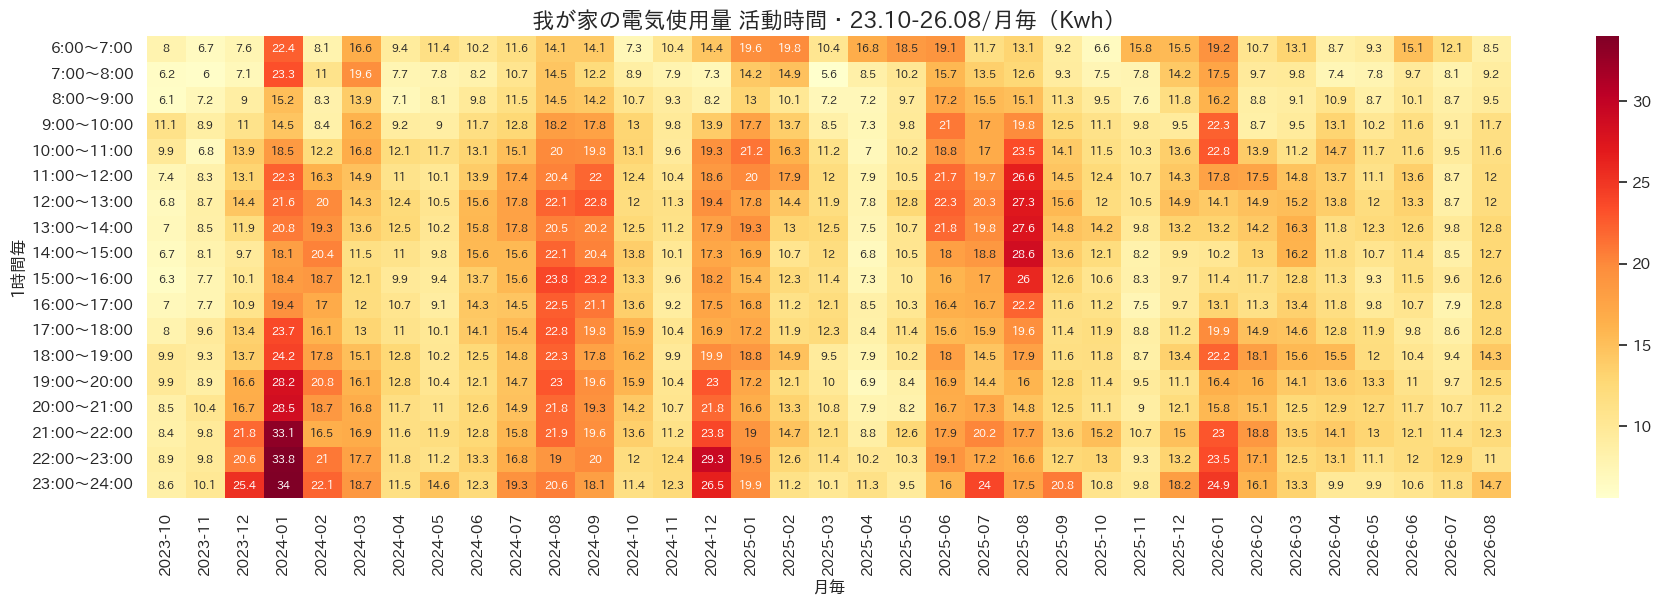

In [76]:
cols = [0] + list(range(2,26))
denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                 index_col=0,   
                 parse_dates=True) 
denki = denki.resample('1ME').sum()
denki.index = denki.index.strftime('%Y-%m')
denki = denki.drop(index=['2026-09'])
denki = denki.iloc[:, 6:] #起きてるだろう時間帯だけ

denki_3y2 = denki.T
denki_3y2

plt.figure(figsize=(22, 6))
seaborn.heatmap(denki_3y2, annot=True, fmt='g',  cmap='YlOrRd',  annot_kws={'size':8})
plt.ylabel('1時間毎')
plt.xlabel('月毎')
plt.title('我が家の電気使用量 活動時間・23.10-26.08/月毎（Kwh）', fontsize=16)

Text(0.5, 1.0, '我が家の電気料金 活動時間・23.10-26.08/月毎（¥）')

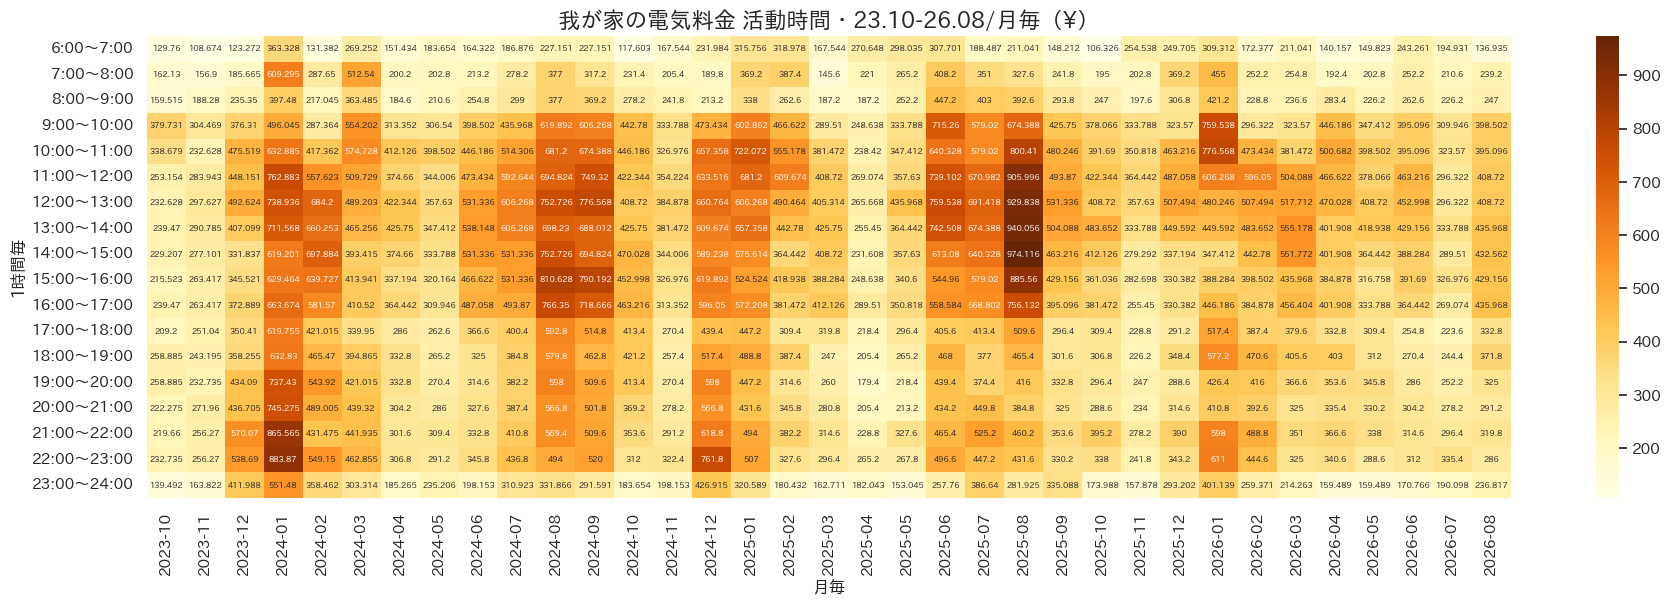

In [77]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2

denki = denki.drop(index=['2026-09'])
denki = denki.iloc[:, 6:] #起きてるだろう時間帯だけ

denki_3y4 = denki.T
denki_3y4

plt.figure(figsize=(22, 6))
seaborn.heatmap(denki_3y4, annot=True, fmt='g',  cmap='YlOrBr',  annot_kws={'size':6})
plt.ylabel('1時間毎')
plt.xlabel('月毎')
plt.title('我が家の電気料金 活動時間・23.10-26.08/月毎（¥）', fontsize=16)

## 夜間の使用電力
夜間の使用電力も、月毎によって大きく差があるね。特に**冬は使用電力が多く**て、**夏は使用電力が少なく**見えるよ。  
夜間帯で主に電力を使用する機器は、**電気温水器** だよ。温める前の水温によって必要なエネルギーが違うからかな？  
あとは、深夜も暖房機器入れたままの時もあるから気をつけよう。

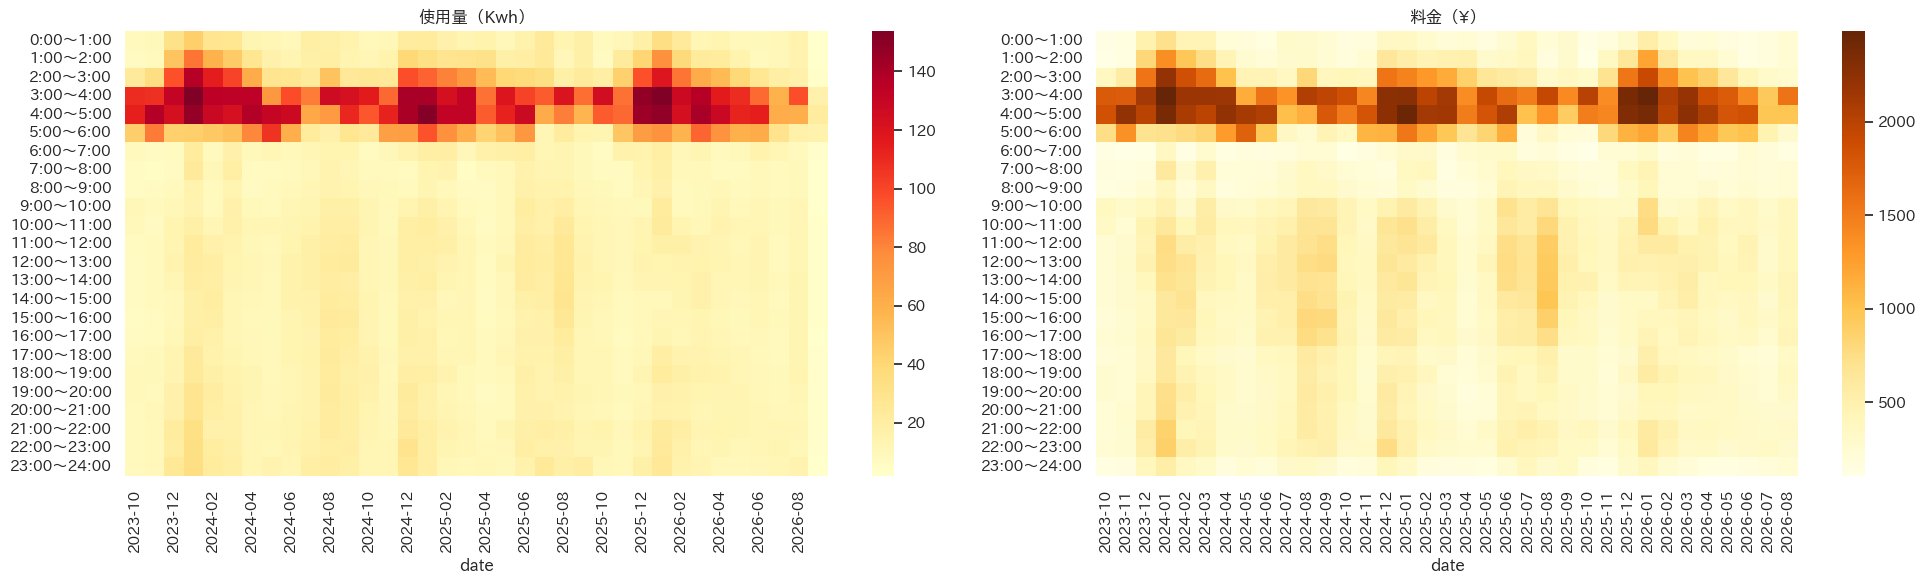

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(denki_3y1, ax=axes[0], cmap='YlOrRd', annot=False, fmt='g')
axes[0].set_title('使用量（Kwh）')

sns.heatmap(denki_3y3, ax=axes[1], cmap='YlOrBr', annot=False, fmt='g')
axes[1].set_title('料金（¥）')

plt.tight_layout()
plt.show()

## 昼間の使用電力
昼間は、夜間ほど使用電力が少なくても、単価が高いことで、夜間よりも料金が高くなっているね。  
昼間は、太陽光や蓄電池などを利用して、使用料を抑えることが必要だね。日中はお出かけするのも良さそうだね。  

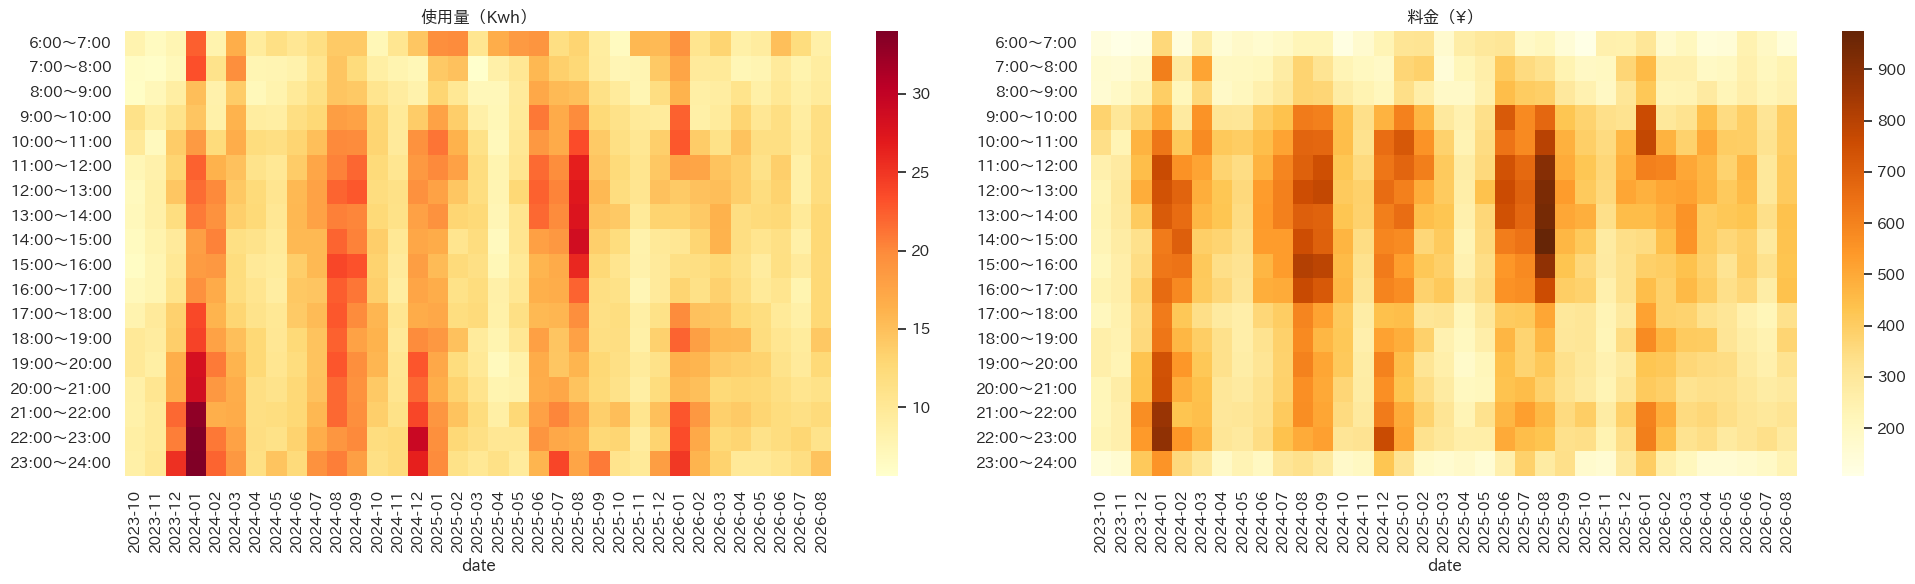

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(denki_3y2, ax=axes[0], cmap='YlOrRd', annot=False, fmt='g')
axes[0].set_title('使用量（Kwh）')

sns.heatmap(denki_3y4, ax=axes[1], cmap='YlOrBr', annot=False, fmt='g')
axes[1].set_title('料金（¥）')

plt.tight_layout()
plt.show()

## 四半期ごとに見てみる
どの年も、Q1（10月〜12月）にピーク使用量があるね。Q2（1月〜3月）の方が寒いのかなと思っていたけど、気温だけの影響ではないのかも？

Text(0.5, 1.0, '我が家の電気使用量 24時間・四半期毎（Kwh）')

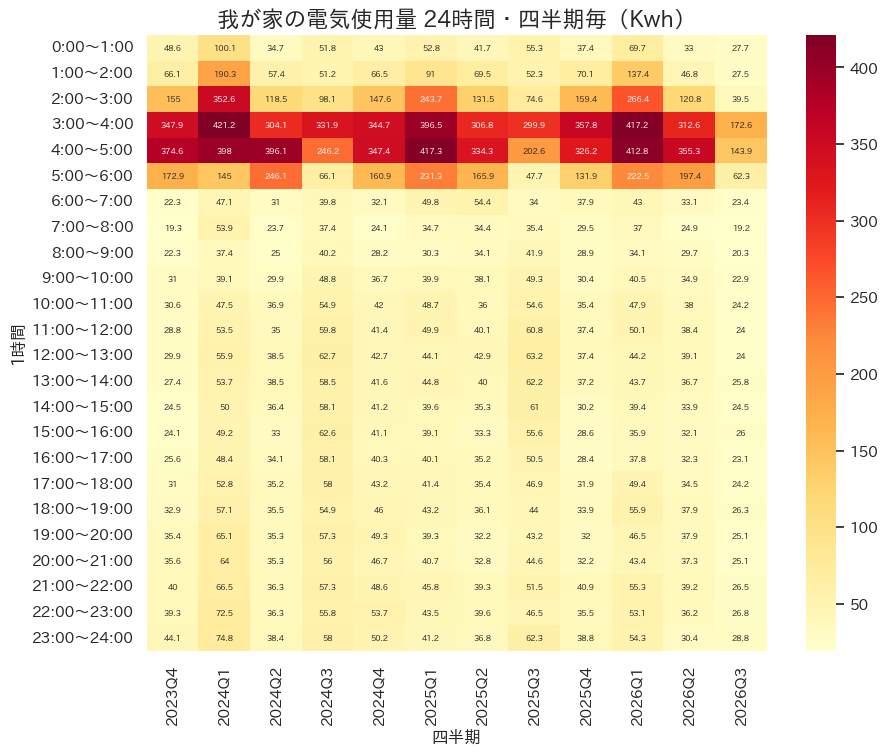

In [39]:
denki = pd.read_csv('denki.csv',
                usecols=[0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], 
                 index_col=0,   
                 parse_dates=True) 
denki_Q = denki.groupby(denki.index.to_period('Q')).sum()
denki_Q1 = denki_Q.T
denki_Q1

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki_Q1, annot=True, fmt='g',  cmap='YlOrRd',  annot_kws={'size':6})
plt.ylabel('1時間')
plt.xlabel('四半期')
plt.title('我が家の電気使用量 24時間・四半期毎（Kwh）', fontsize=16)

Text(0.5, 1.0, '我が家の電気料金 24時間・四半期毎（¥）')

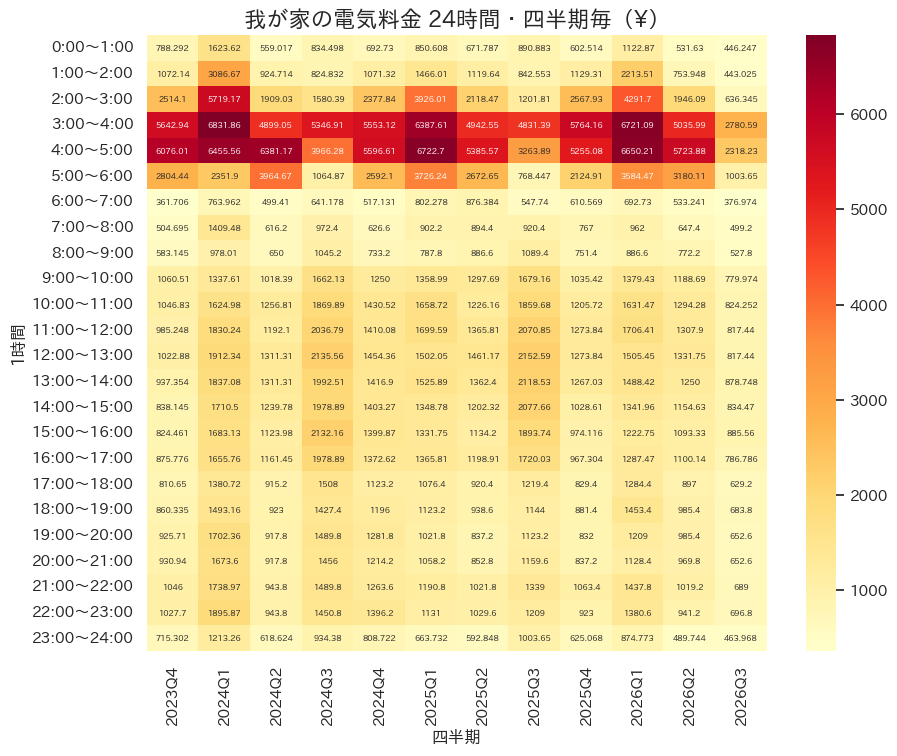

In [40]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2

denki_Q = denki.groupby(denki.index.asfreq('Q')).sum()
denki_Q3 = denki_Q.T
denki_Q3

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki_Q3, annot=True, fmt='g',  cmap='YlOrRd',  annot_kws={'size':6})
plt.ylabel('1時間')
plt.xlabel('四半期')
plt.title('我が家の電気料金 24時間・四半期毎（¥）', fontsize=16)

Text(0.5, 1.0, '我が家の電気使用量\u3000活動時・間四半期毎（Kwh）')

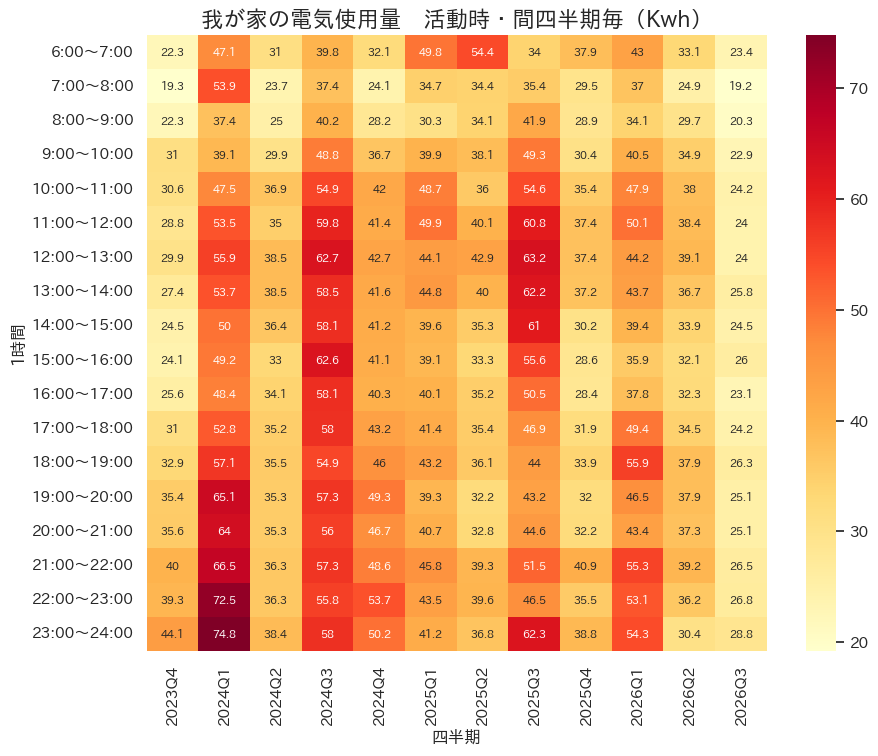

In [41]:
denki = pd.read_csv('denki.csv',
                usecols=[0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], 
                 index_col=0,   
                 parse_dates=True) 
denki_Q = denki.groupby(denki.index.to_period('Q')).sum()
denki_Q = denki_Q.iloc[:, 6:] #起きてるだろう時間帯だけ
denki_Q2 = denki_Q.T
denki_Q2

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki_Q2, annot=True, fmt='g', cmap='YlOrRd',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('四半期')
plt.title('我が家の電気使用量　活動時・間四半期毎（Kwh）', fontsize=16)

#plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, '我が家の電気料金\u3000活動時・間四半期毎（¥）')

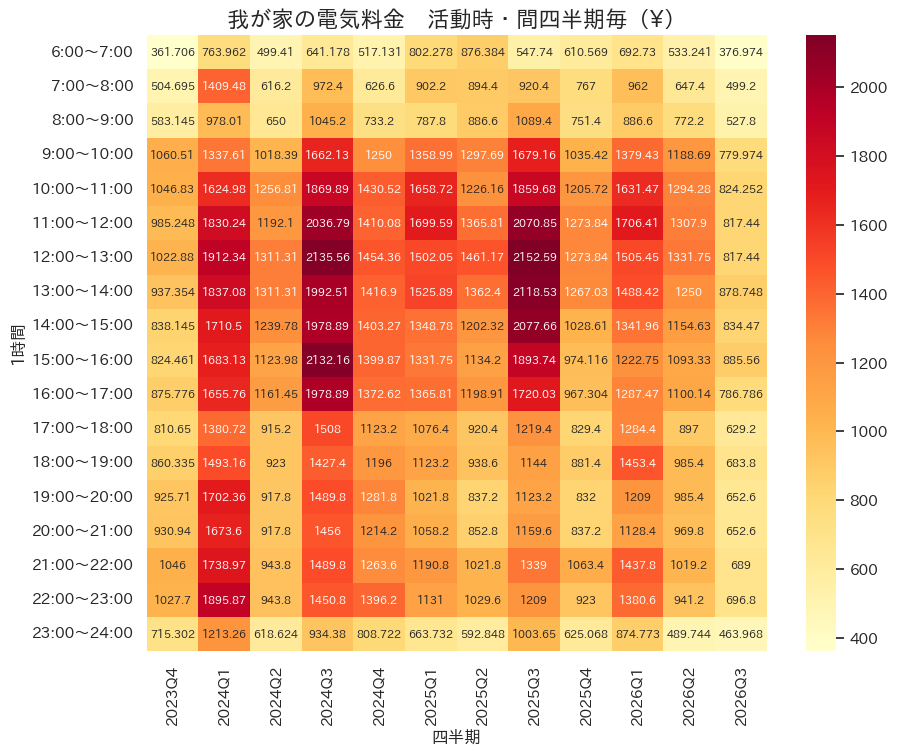

In [43]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2

denki_Q = denki.groupby(denki.index.asfreq('Q')).sum()
denki_Q = denki_Q.iloc[:, 6:] #起きてるだろう時間帯だけ
denki_Q4 = denki_Q.T
denki_Q4

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki_Q4, annot=True, fmt='g', cmap='YlOrRd',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('四半期')
plt.title('我が家の電気料金　活動時・間四半期毎（¥）', fontsize=16)

#plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')

## 四半期ごと　使用量｜料金　24時間比較

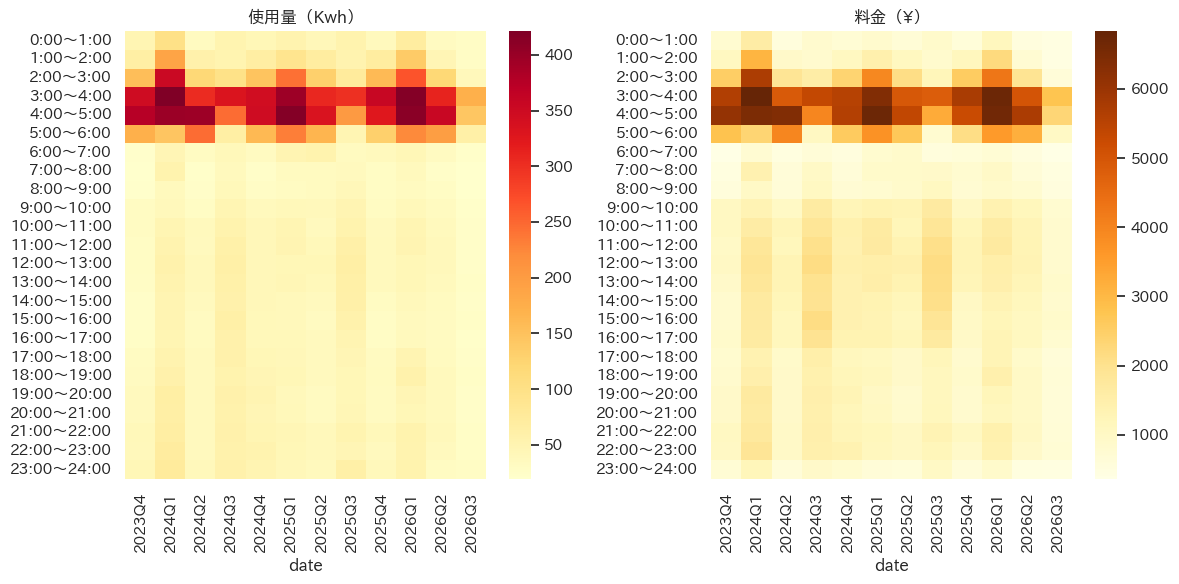

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(denki_Q1, ax=axes[0], cmap='YlOrRd', annot=False, fmt='g')
axes[0].set_title('使用量（Kwh）')

sns.heatmap(denki_Q3, ax=axes[1], cmap='YlOrBr', annot=False, fmt='g')
axes[1].set_title('料金（¥）')

plt.tight_layout()
plt.show()

## 四半期ごと　使用量｜料金　活動時間比較

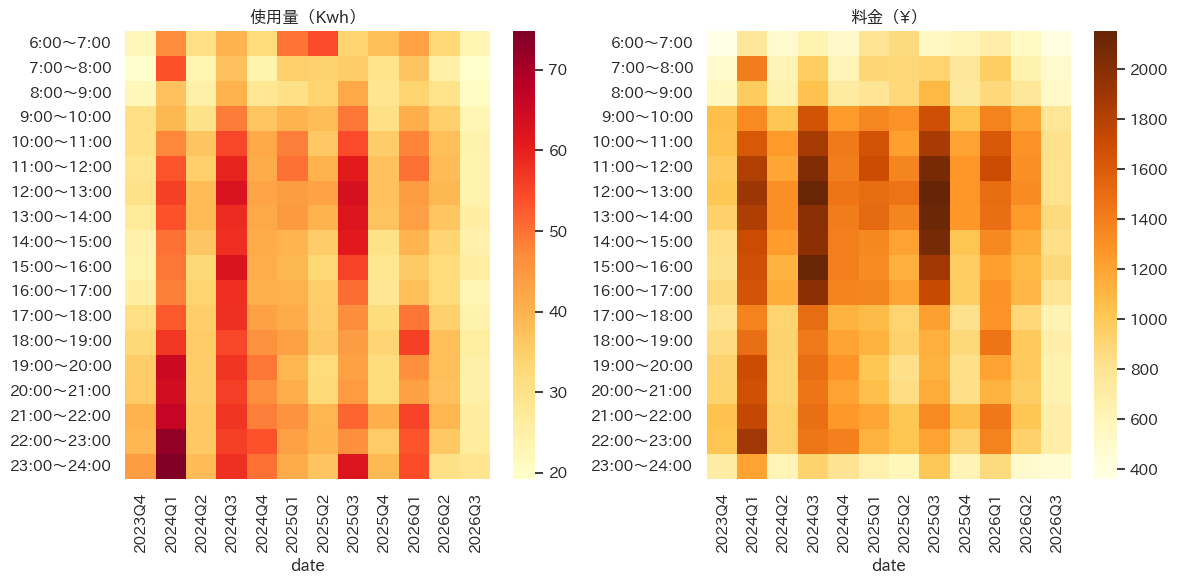

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(denki_Q2, ax=axes[0], cmap='YlOrRd', annot=False, fmt='g')
axes[0].set_title('使用量（Kwh）')

sns.heatmap(denki_Q4, ax=axes[1], cmap='YlOrBr', annot=False, fmt='g')
axes[1].set_title('料金（¥）')

plt.tight_layout()
plt.show()

## 気象データと比較

気象庁Webページの[「過去の気象データ・ダウンロード」](https://www.data.jma.go.jp/risk/obsdl/)より、居住地域の対象期間CSVデータをダウンロードしたよ。  

In [49]:
tenki = pd.read_csv('tenki.csv',
                    skiprows=3,
                    sep=None, engine='python',
                    encoding='cp932')
tenki = tenki.iloc[:, 0:2]
tenki = tenki.set_index(tenki.columns[0])
tenki.index = pd.to_datetime(tenki.index)
#tenki['年月'] = tenki.index.strftime('%Y-%m')
tenki['年月'] = tenki.index.to_period('M')
tenki['時間'] = tenki.index.strftime('%H:%M')
tenki_p = tenki.pivot_table(
    index='時間',        
    columns='年月',      
    values='気温(℃)'
)
tenki_p = tenki_p.round(1)
tenki_p

年月,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,...,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
時間,,,,,,,,,,,,,,,,,,,,,
00:00,15.0,12.3,6.9,5.2,7.4,7.4,14.3,16.6,19.8,25.1,...,7.2,3.5,5.6,8.9,14.1,16.9,19.6,24.1,25.2,23.6
01:00,14.9,12.1,6.7,5.2,7.2,7.0,14.1,16.4,19.4,24.8,...,7.3,3.4,5.3,8.6,14.0,16.6,19.4,23.8,25.0,23.6
02:00,14.6,11.8,6.3,4.9,7.0,7.0,13.7,16.1,19.1,24.6,...,7.1,3.3,5.0,8.4,13.8,16.5,19.3,23.7,24.8,23.5
03:00,14.4,11.7,6.0,4.9,6.9,6.8,13.6,16.0,19.0,24.4,...,6.9,2.7,4.8,8.1,13.7,16.4,19.2,23.5,24.6,23.4
04:00,14.3,11.6,6.0,5.0,6.7,6.4,13.6,15.9,18.9,24.2,...,6.7,2.5,4.6,7.9,13.4,16.3,19.1,23.5,24.5,23.2
05:00,14.2,11.6,6.0,4.9,6.5,6.3,13.5,16.0,18.9,24.1,...,6.4,2.7,4.5,7.8,13.3,16.2,19.0,23.2,24.3,23.2
06:00,14.2,11.5,5.8,4.6,6.5,6.2,13.5,16.5,19.2,24.2,...,6.3,2.5,4.8,7.8,13.4,16.8,19.4,23.5,24.4,23.2
07:00,14.8,11.7,5.7,4.6,6.5,6.6,14.6,17.4,20.2,25.4,...,6.4,2.2,4.9,8.2,14.2,18.0,20.1,24.6,25.3,23.6
08:00,16.1,12.9,6.8,5.5,7.2,8.0,16.0,18.5,21.4,27.3,...,7.3,3.4,6.2,9.7,15.4,19.4,21.1,26.5,26.8,24.2


In [50]:
tenki_p = tenki_p.round(1)
tenki_night = tenki_p.iloc[0:7]
tenki_night

年月,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,...,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
時間,,,,,,,,,,,,,,,,,,,,,
00:00,15.0,12.3,6.9,5.2,7.4,7.4,14.3,16.6,19.8,25.1,...,7.2,3.5,5.6,8.9,14.1,16.9,19.6,24.1,25.2,23.6
01:00,14.9,12.1,6.7,5.2,7.2,7.0,14.1,16.4,19.4,24.8,...,7.3,3.4,5.3,8.6,14.0,16.6,19.4,23.8,25.0,23.6
02:00,14.6,11.8,6.3,4.9,7.0,7.0,13.7,16.1,19.1,24.6,...,7.1,3.3,5.0,8.4,13.8,16.5,19.3,23.7,24.8,23.5
03:00,14.4,11.7,6.0,4.9,6.9,6.8,13.6,16.0,19.0,24.4,...,6.9,2.7,4.8,8.1,13.7,16.4,19.2,23.5,24.6,23.4
04:00,14.3,11.6,6.0,5.0,6.7,6.4,13.6,15.9,18.9,24.2,...,6.7,2.5,4.6,7.9,13.4,16.3,19.1,23.5,24.5,23.2
05:00,14.2,11.6,6.0,4.9,6.5,6.3,13.5,16.0,18.9,24.1,...,6.4,2.7,4.5,7.8,13.3,16.2,19.0,23.2,24.3,23.2
06:00,14.2,11.5,5.8,4.6,6.5,6.2,13.5,16.5,19.2,24.2,...,6.3,2.5,4.8,7.8,13.4,16.8,19.4,23.5,24.4,23.2


In [51]:
tenki_p = tenki_p.round(1)
tenki_day = tenki_p.iloc[10:17]
tenki_day

年月,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,...,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
時間,,,,,,,,,,,,,,,,,,,,,
10:00,19.8,15.8,10.2,8.5,10.1,10.9,19.1,21.3,24.8,31.3,...,10.6,7.1,9.9,13.0,18.6,22.7,23.5,29.6,30.3,26.0
11:00,21.5,17.0,11.5,9.7,11.2,11.9,20.4,22.6,25.7,32.0,...,12.0,8.7,11.6,14.3,19.5,23.8,24.4,30.9,31.3,26.2
12:00,22.7,18.0,12.3,10.4,12.0,12.7,21.1,23.2,26.0,32.9,...,13.0,9.5,12.8,15.2,19.9,24.4,24.9,31.2,31.9,26.6
13:00,22.9,18.5,13.1,11.0,12.6,13.2,21.1,23.5,26.3,33.2,...,13.5,9.8,13.5,15.7,20.4,24.6,25.0,31.4,31.9,26.6
14:00,22.8,18.7,13.4,11.0,12.8,13.2,20.8,23.7,26.1,33.0,...,13.3,9.9,13.8,15.7,20.1,24.5,24.8,31.4,31.9,26.4
15:00,22.6,18.1,12.6,10.5,12.8,13.1,20.5,23.2,26.0,32.6,...,12.8,9.6,13.6,15.6,19.9,24.2,24.3,30.9,31.6,25.9
16:00,21.2,16.6,11.3,10.0,12.2,12.7,19.8,22.7,25.4,31.7,...,11.8,8.8,13.0,14.9,19.1,23.5,23.7,30.1,31.0,25.7


## 気温の変化を見てみる
気温の変化によって、夜間の使用電力に変化は生じるのかな？

Text(0.5, 1.0, '居住エリア気温 24時間・月毎（Kwh）')

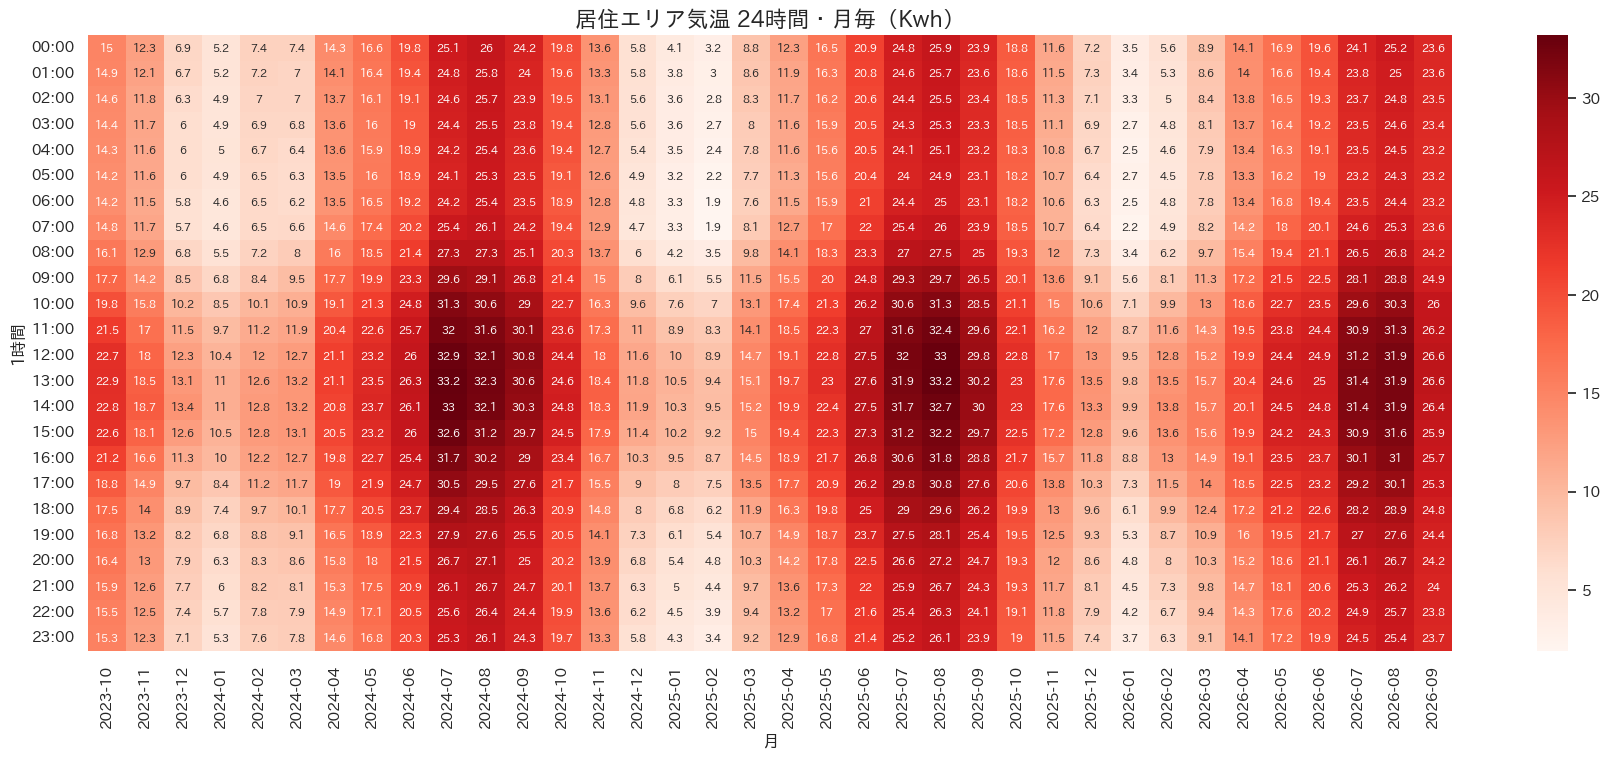

In [87]:
plt.figure(figsize=(22, 8))
seaborn.heatmap(tenki_p, annot=True, fmt='g', cmap='Reds',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('月')
plt.title('居住エリア気温 24時間・月毎（Kwh）', fontsize=16)

## 夜間の使用電力と日中の気温、夜間の気温を比較してみたよ

Text(0.5, 1.0, '我が家の電気使用量 24時間・23.10-26.08/月毎（Kwh）')

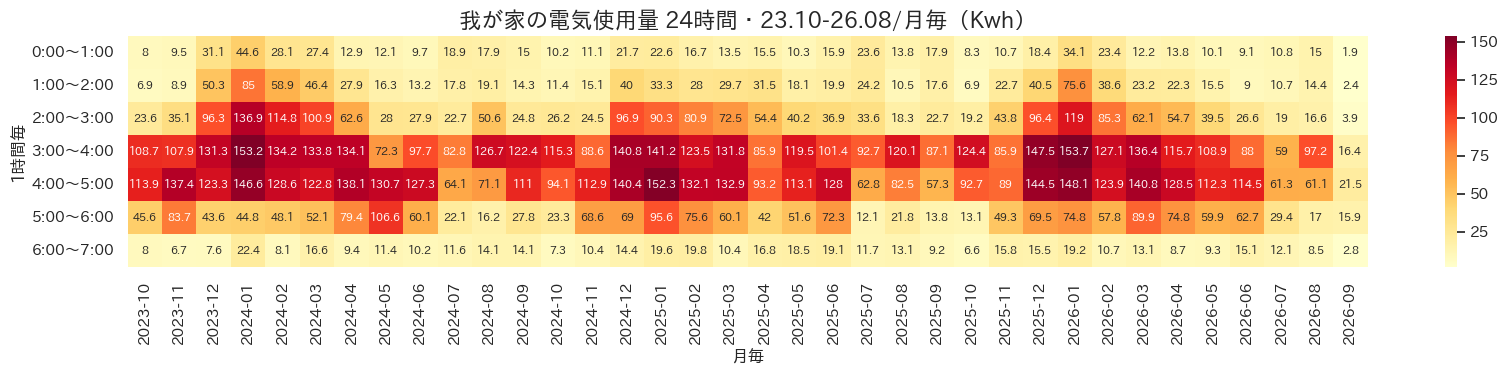

In [56]:
cols = [0] + list(range(2,26))
denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                 index_col=0,   
                 parse_dates=True) 
denki = denki.resample('1ME').sum()
denki.index = denki.index.strftime('%Y-%m')

denki_3y1 = denki.T
denki_3ynight = denki_3y1.iloc[0:7]
denki_3ynight

plt.figure(figsize=(20, 3))
seaborn.heatmap(denki_3ynight, annot=True, fmt='g',  cmap='YlOrRd',  annot_kws={'size':8})
plt.ylabel('1時間毎')
plt.xlabel('月毎')
plt.title('我が家の電気使用量 24時間・23.10-26.08/月毎（Kwh）', fontsize=16)

Text(0.5, 1.0, '居住エリア気温 夜間・月毎（℃）')

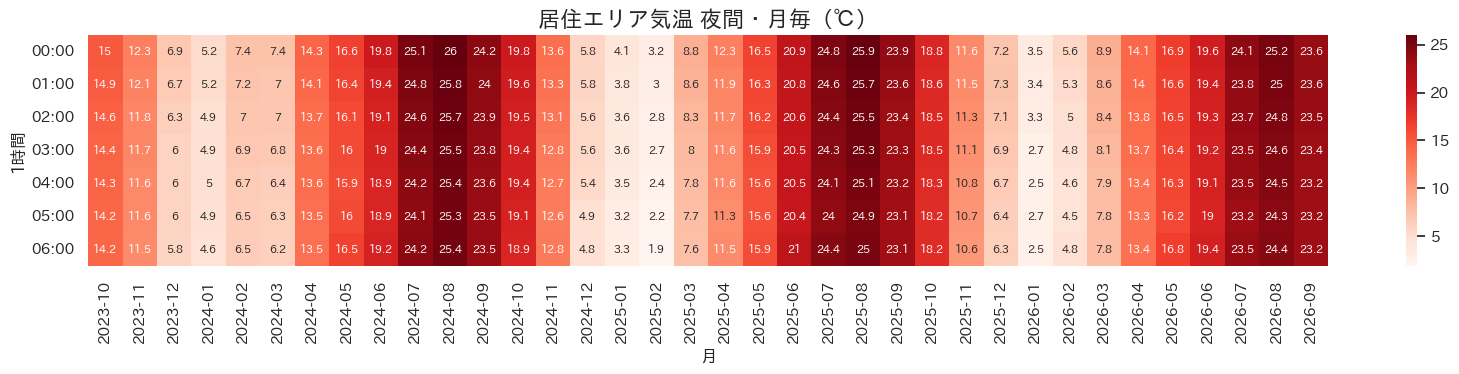

In [61]:
plt.figure(figsize=(20, 3))
seaborn.heatmap(tenki_night, annot=True, fmt='g', cmap='Reds',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('月')
plt.title('居住エリア気温 夜間・月毎（℃）', fontsize=16)

Text(0.5, 1.0, '居住エリア気温 昼間・月毎（℃）')

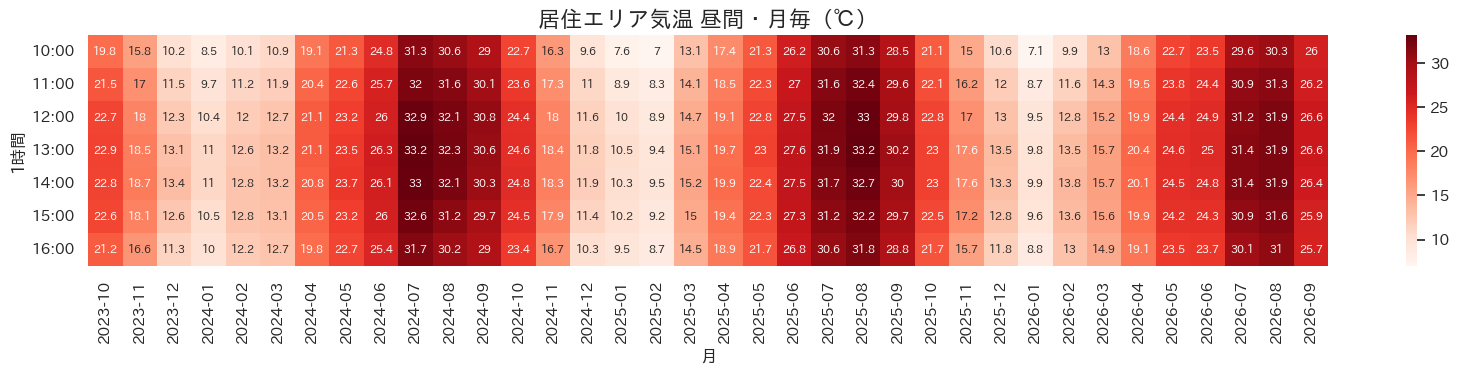

In [62]:
plt.figure(figsize=(20, 3))
seaborn.heatmap(tenki_day, annot=True, fmt='g', cmap='Reds',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('月')
plt.title('居住エリア気温 昼間・月毎（℃）', fontsize=16)

## 気温と電力使用量の関係

夜間電力で使用する機器に、**電機温水器**があるよ。水を水道からタンクに溜めて温める機器だよ。これが夜間電力を大半を締めているよ。
水が冷たいと、温めるのにエネルギーをいっぱい使う。水がぬるいと、エネルギーは少なくて良さそうだね。

昼間の気温が高いと水がぬるくなって、省エネになりそうだね。
気温の変化と比較してみよう。  

気温が低い月は、夜間の使用電力は増えているね。
特に、1月は使用量が増えているね。　2月は気温が低いけど、1月よりも使用量が少ないね。2月が28日間（または29日間）で、1月よりも日数が少ないからかもしれないね。
12月よりも気温の低い2月が、12月と使用量が変わってなさそうに見えるのは、12月よりも日数が少ないからだね。

暖かい日が続けば、電気使用量は減るかもしれないけど
雪が降らないとウィンタースポーツが楽しめないから、困るね。

昼間に水を温かくする方法があると良いね。

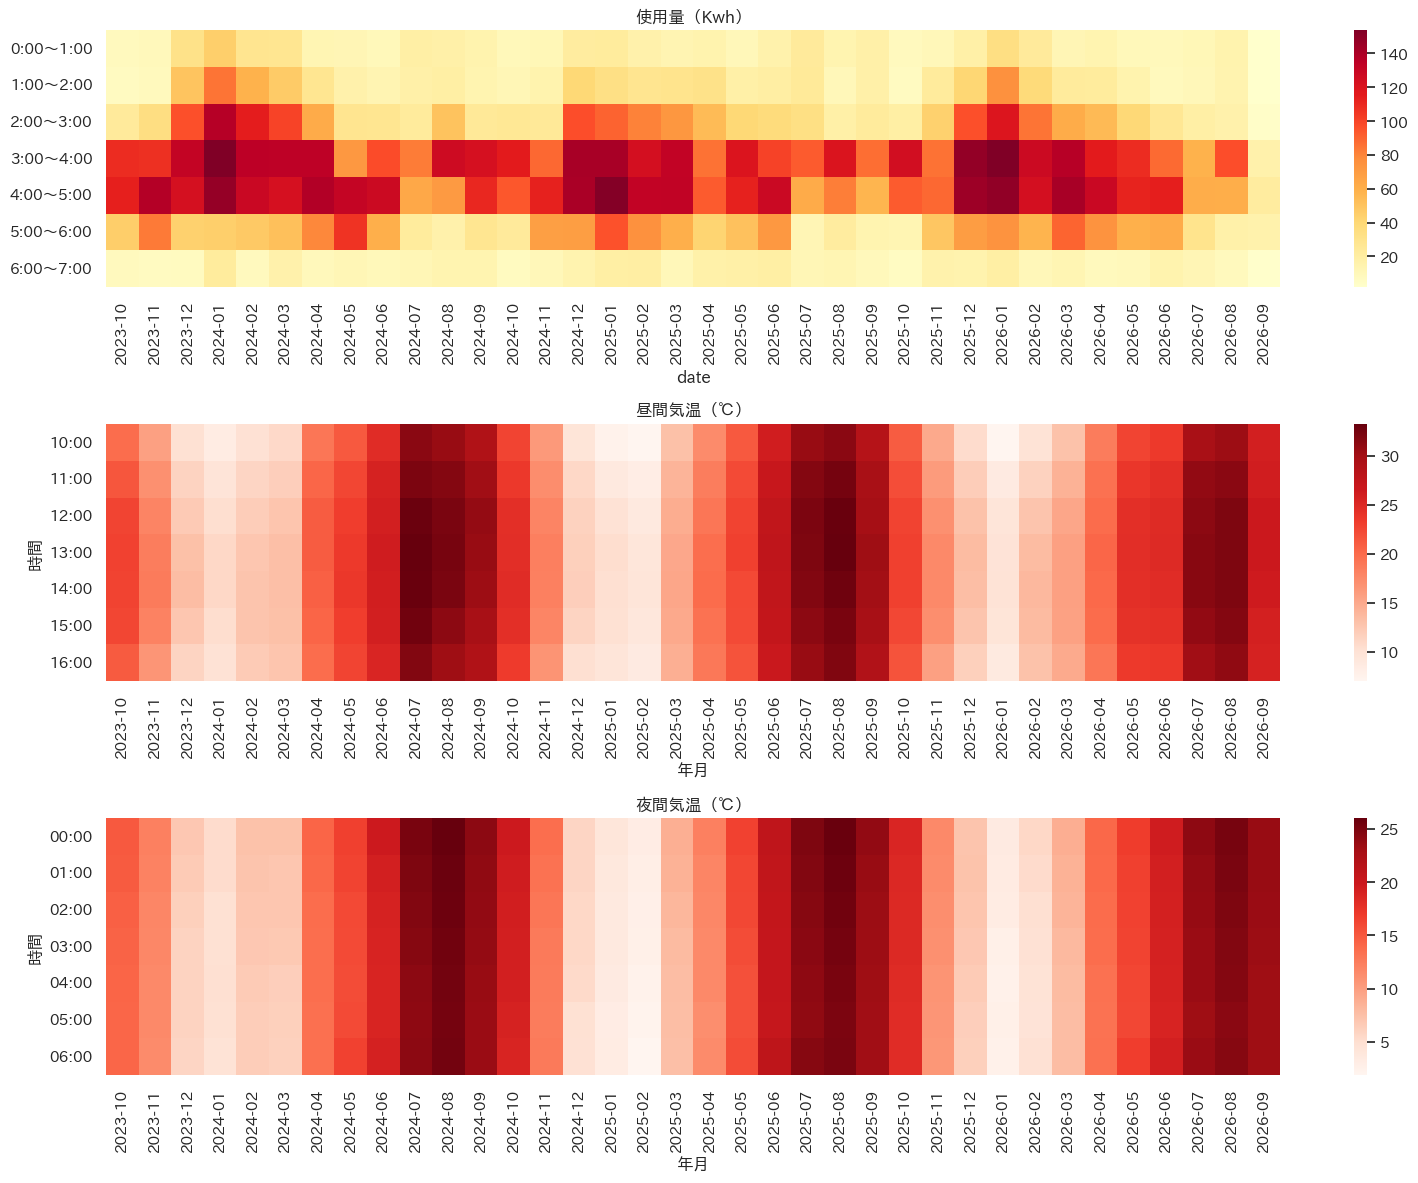

In [95]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

sns.heatmap(denki_3ynight, ax=axes[0], cmap='YlOrRd', annot=False, fmt='g')
axes[0].set_title('使用量（Kwh）')

sns.heatmap(tenki_day, ax=axes[1], cmap='Reds', annot=False, fmt='g')
axes[1].set_title('昼間気温（℃）')

sns.heatmap(tenki_night, ax=axes[2], cmap='Reds', annot=False, fmt='g')
axes[2].set_title('夜間気温（℃）')

plt.tight_layout()
plt.show()

## 曜日ごとに見てみる
3年分のデータを曜日ごとに、フィルタリングしてみたよ。曜日では、自宅にいること多い土日は多いかなと思っていたよ。  
他はそんなに差はないかなと思っていたけど火曜日の夜間帯が異常に高い結果が見えたよ。日中も火曜日多かったよ。火と日に、電気代が燃え上がっているんだね。

Text(0.5, 1.0, '我が家の電気使用量 24時間・曜日毎（Kwh）')

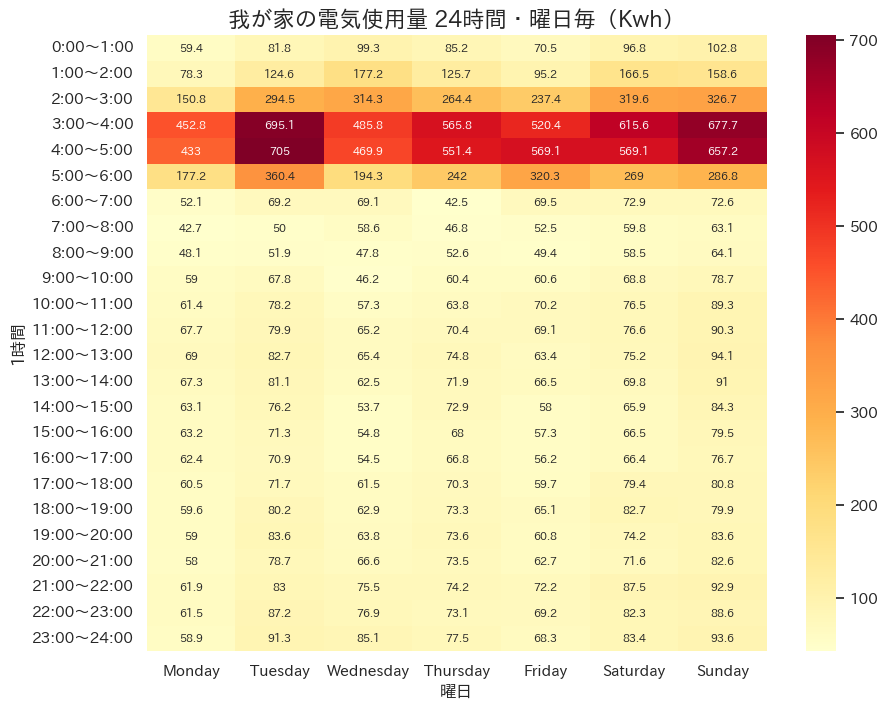

In [92]:
denki = pd.read_csv('denki.csv',
                    usecols=[0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], 
                 index_col=0,   
                 parse_dates=True) 
denki = denki.resample('1ME').sum()
denki['weekday'] = denki.index.day_name()
denki_weekday = denki.groupby(['weekday'], as_index=False).sum()
denki_weekday = denki_weekday.set_index('weekday')
youbi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
denki_weekday = denki_weekday.reindex(level='weekday', labels=youbi)
denki_weekday_t1 = denki_weekday.T
denki_weekday_t1

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki_weekday_t1, annot=True, fmt='g', cmap='YlOrRd',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('曜日')
plt.title('我が家の電気使用量 24時間・曜日毎（Kwh）', fontsize=16)

Text(0.5, 1.0, '我が家の電気使用量 活動時間・曜日毎（Kwh）')

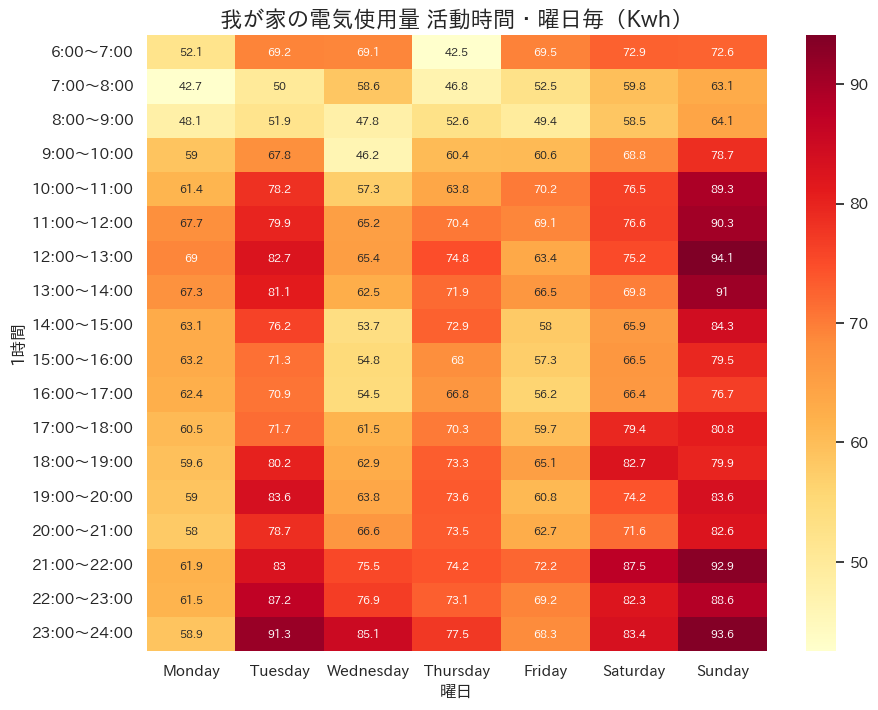

In [91]:
denki = pd.read_csv('denki.csv',
                    usecols=[0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], 
                 index_col=0,   
                 parse_dates=True) 
denki = denki.resample('1ME').sum()
denki['weekday'] = denki.index.day_name()

denki_weekday = denki.groupby(['weekday'], as_index=False).sum()
denki_weekday = denki_weekday.set_index('weekday')

youbi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
denki_weekday = denki_weekday.reindex(level='weekday', labels=youbi)

denki_weekday = denki_weekday.iloc[:, 6:] #起きてるだろう時間帯だけ

denki_weekday_t2 = denki_weekday.T

denki_weekday_t2

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki_weekday_t2, annot=True, fmt='g',  cmap='YlOrRd',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('曜日')
plt.title('我が家の電気使用量 活動時間・曜日毎（Kwh）', fontsize=16)

Text(0.5, 1.0, '我が家の電気料金 24時間・曜日毎（¥）')

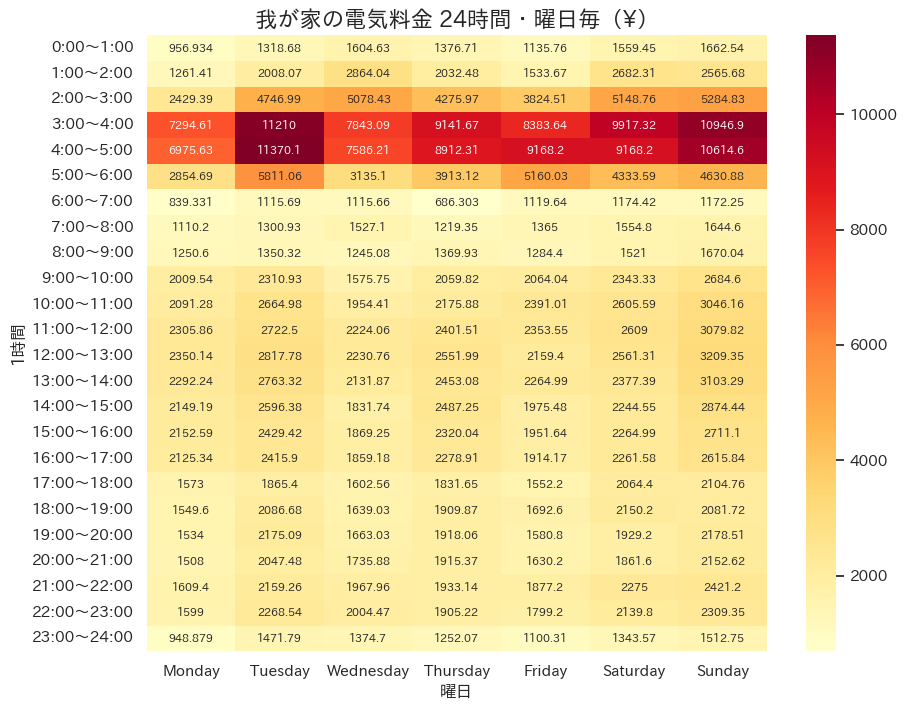

In [90]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki['weekday'] = denki.index.day_name()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2


denki_weekday = denki.groupby(['weekday'], as_index=False).sum()
denki_weekday = denki_weekday.set_index('weekday')
youbi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
denki_weekday = denki_weekday.reindex(level='weekday', labels=youbi)
denki_weekday_t3 = denki_weekday.T
denki_weekday_t3

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki_weekday_t3, annot=True, fmt='g', cmap='YlOrRd',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('曜日')
plt.title('我が家の電気料金 24時間・曜日毎（¥）', fontsize=16)

Text(0.5, 1.0, '我が家の電気料金 活動時間・曜日毎（¥）')

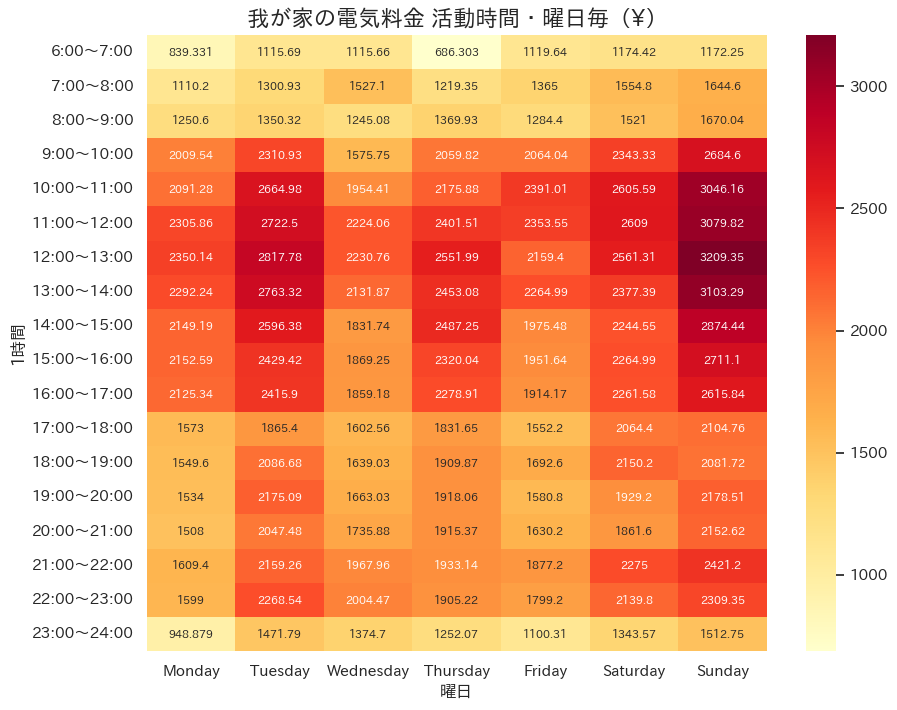

In [89]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki['weekday'] = denki.index.day_name()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2

denki_weekday = denki.groupby(['weekday'], as_index=False).sum()
denki_weekday = denki_weekday.set_index('weekday')

youbi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
denki_weekday = denki_weekday.reindex(level='weekday', labels=youbi)

denki_weekday = denki_weekday.iloc[:, 6:] #起きてるだろう時間帯だけ

denki_weekday_t4 = denki_weekday.T

denki_weekday_t4

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki_weekday_t4, annot=True, fmt='g',  cmap='YlOrRd',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('曜日')
plt.title('我が家の電気料金 活動時間・曜日毎（¥）', fontsize=16)

## 曜日ごと　使用量｜料金　24時間比較

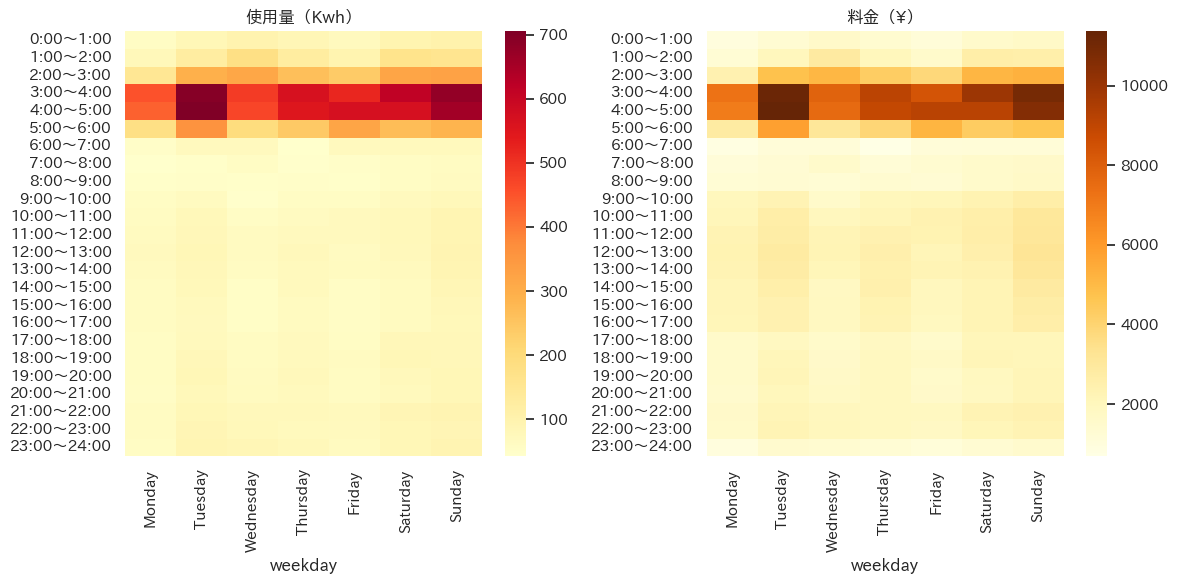

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(denki_weekday_t1, ax=axes[0], cmap='YlOrRd', annot=False, fmt='g')
axes[0].set_title('使用量（Kwh）')

sns.heatmap(denki_weekday_t3, ax=axes[1], cmap='YlOrBr', annot=False, fmt='g')
axes[1].set_title('料金（¥）')

plt.tight_layout()
plt.show()

## 曜日ごと　使用量｜料金　活動時間比較

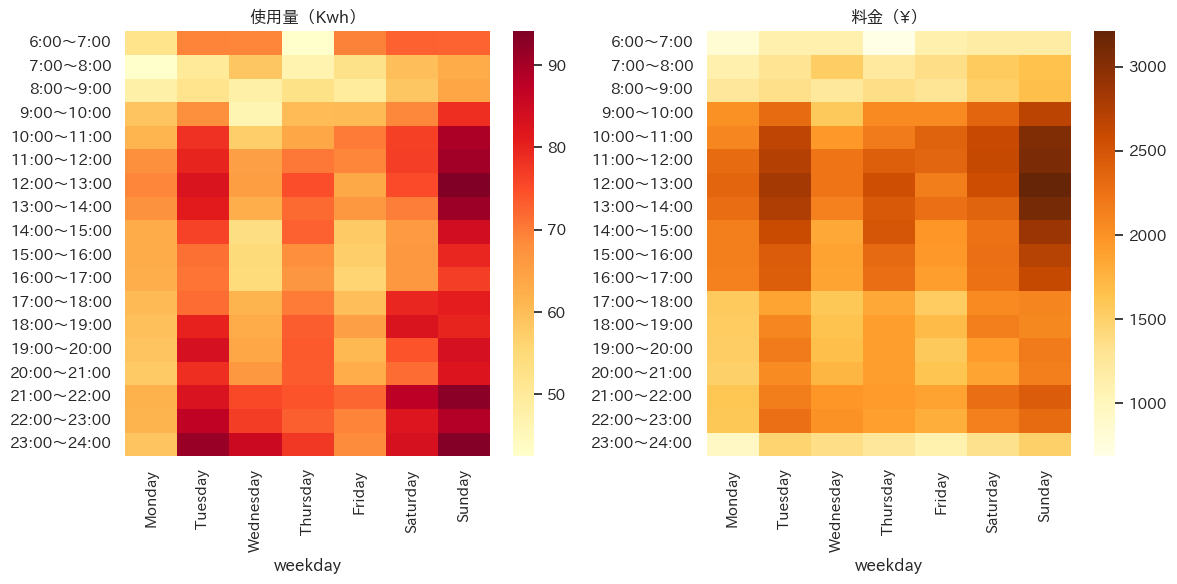

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(denki_weekday_t2, ax=axes[0], cmap='YlOrRd', annot=False, fmt='g')
axes[0].set_title('使用量（Kwh）')

sns.heatmap(denki_weekday_t4, ax=axes[1], cmap='YlOrBr', annot=False, fmt='g')
axes[1].set_title('料金（¥）')

plt.tight_layout()
plt.show()

## 2024年と2025年

Text(0.5, 55.249999999999986, '月')

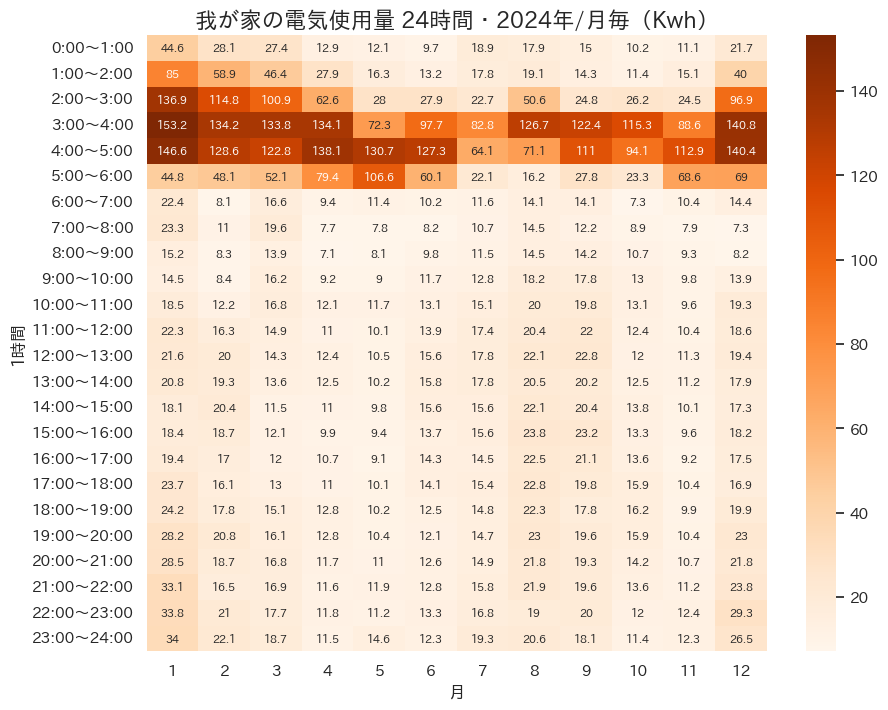

In [43]:
cols = [0] + list(range(2,26))
denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                 index_col=0,   
                 parse_dates=True) 
denki = denki.resample('1ME').sum()
denki['year'] = denki.index.year
denki['month'] = denki.index.month
denki_month = denki.groupby(['month','year'], as_index=False).sum()
denki2024 = denki_month[denki_month['year'] == 2024].drop(columns='year')
denki2024 = denki2024.set_index('month')

denki2024_t1 = denki2024.T
denki2024_t1

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki2024_t1, annot=True, fmt='g', cmap='Oranges',  annot_kws={'size':8})
plt.title('我が家の電気使用量 24時間・2024年/月毎（Kwh）', fontsize=16)
plt.ylabel('1時間')
plt.xlabel('月')

#plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')

Text(0.5, 55.249999999999986, '月')

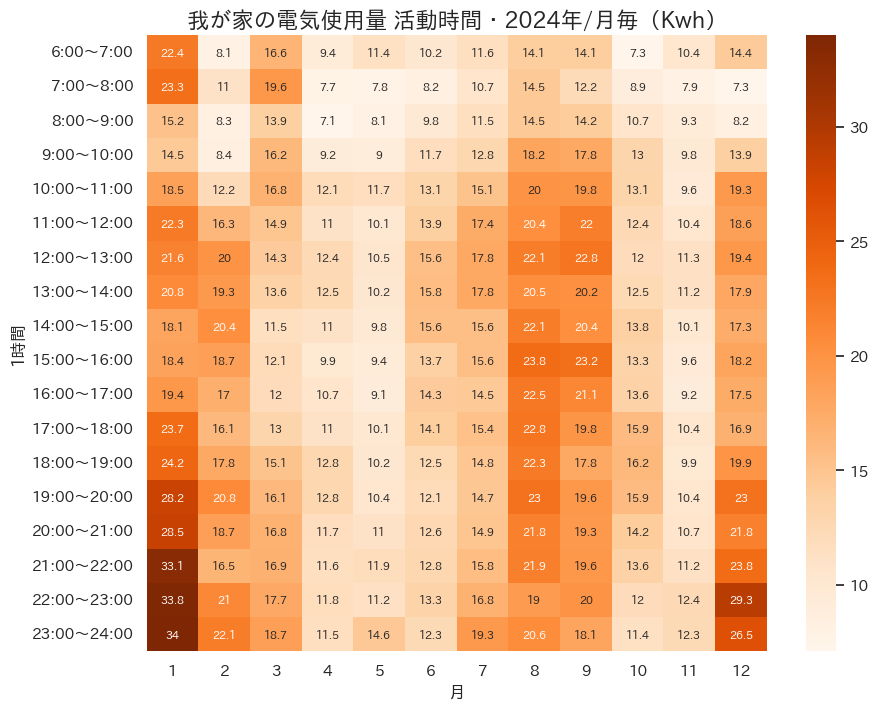

In [44]:
cols = [0] + list(range(2,26))
denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                 index_col=0,   
                 parse_dates=True) 
denki = denki.resample('1ME').sum()
denki['year'] = denki.index.year
denki['month'] = denki.index.month
denki_month = denki.groupby(['month','year'], as_index=False).sum()
denki2024 = denki_month[denki_month['year'] == 2024].drop(columns='year')
denki2024 = denki2024.set_index('month')

denki2024 = denki2024.iloc[:, 6:]#起きてるだろう時間帯だけ

denki2024_t2 = denki2024.T
denki2024_t2

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki2024_t2, annot=True, fmt='g', cmap='Oranges',  annot_kws={'size':8})
plt.title('我が家の電気使用量 活動時間・2024年/月毎（Kwh）', fontsize=16)
plt.ylabel('1時間')
plt.xlabel('月')

#plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')

電気料金 202310-202403 ,　9:00-17:00 , 34.21 , 23:00-7:00 , 16.22 , 17:00-23:00 , 26.15 , 7:00-9:00 , 26.15

電気料金 202404-202609 ,　9:00-17:00 , 34.06 , 23:00-7:00 , 16.11 , 17:00-23:00 , 26.00 , 7:00-9:00 , 26.00 

Text(0.5, 55.249999999999986, '月')

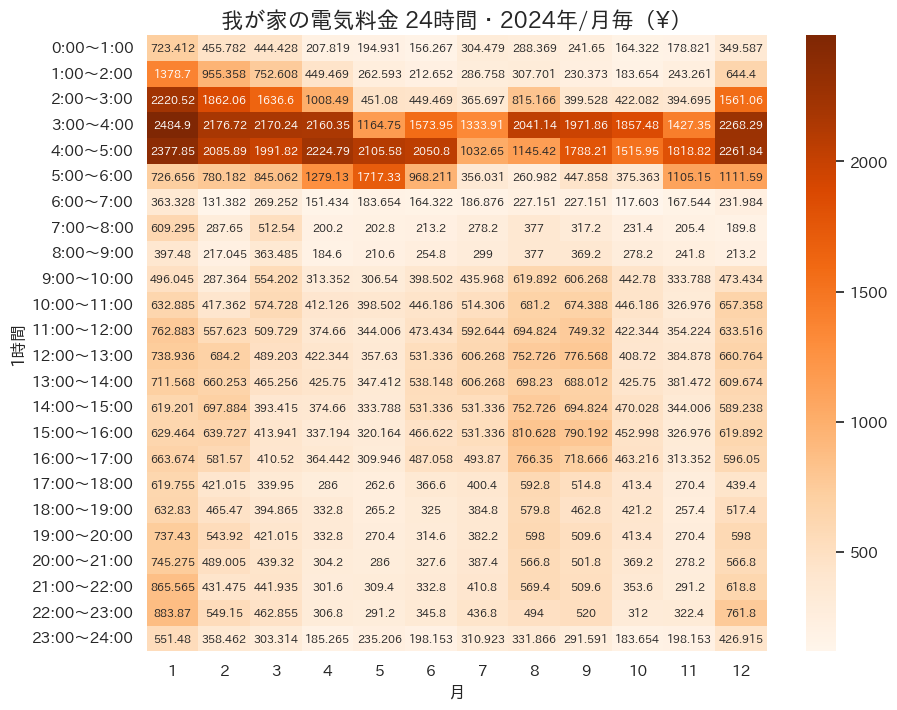

In [42]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2

denki['year'] = denki.index.year
denki['month'] = denki.index.month
denki_month = denki.groupby(['month','year'], as_index=False).sum()
denki2024 = denki_month[denki_month['year'] == 2024].drop(columns='year')
denki2024 = denki2024.set_index('month')

denki2024_t3 = denki2024.T
denki2024_t3

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki2024_t3, annot=True, fmt='g', cmap='Oranges',  annot_kws={'size':8})
plt.title('我が家の電気料金 24時間・2024年/月毎（¥）', fontsize=16)
plt.ylabel('1時間')
plt.xlabel('月')

Text(0.5, 55.249999999999986, '月')

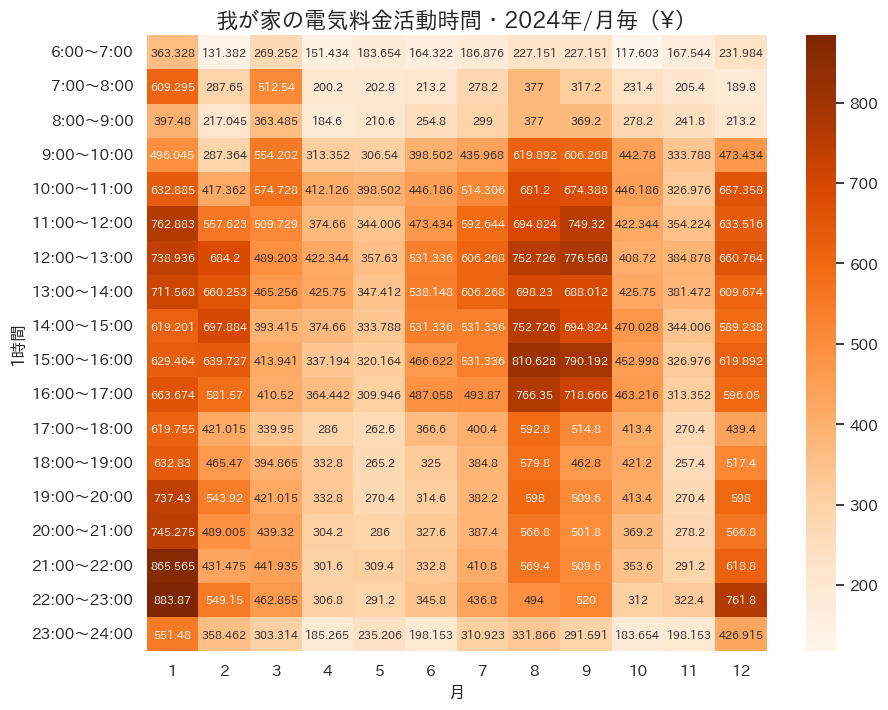

In [41]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2

denki['year'] = denki.index.year
denki['month'] = denki.index.month
denki_month = denki.groupby(['month','year'], as_index=False).sum()
denki2024 = denki_month[denki_month['year'] == 2024].drop(columns='year')
denki2024 = denki2024.set_index('month')

denki2024 = denki2024.iloc[:, 6:]#起きてるだろう時間帯だけ

denki2024_t4 = denki2024.T
denki2024_t4

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki2024_t4, annot=True, fmt='g', cmap='Oranges',  annot_kws={'size':8})
plt.title('我が家の電気料金活動時間・2024年/月毎（¥）', fontsize=16)
plt.ylabel('1時間')
plt.xlabel('月')

Text(0.5, 1.0, '我が家の電気使用量 24時間・2025年/月毎（Kwh）')

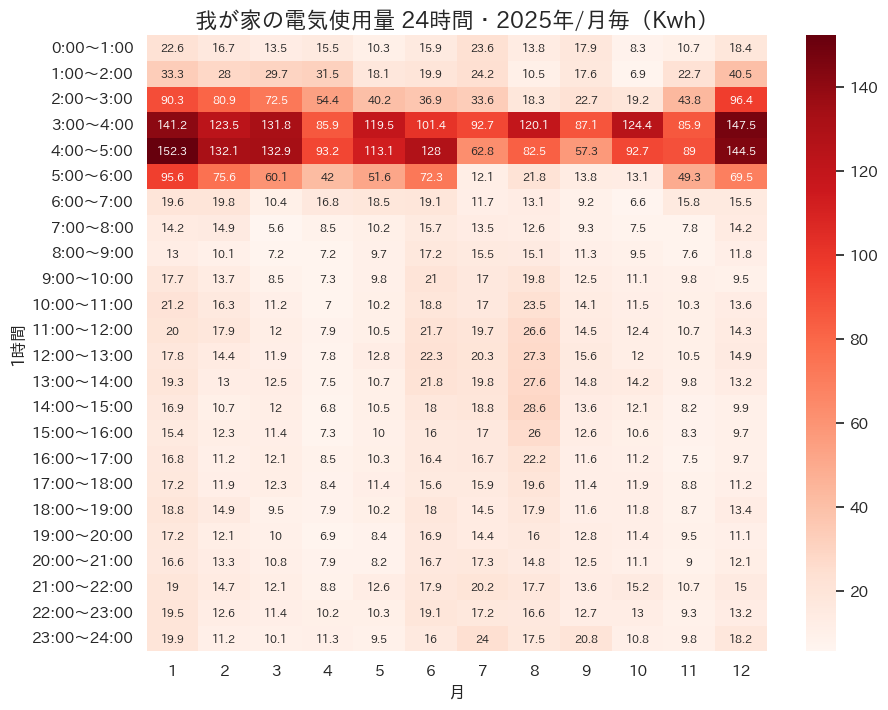

In [48]:
denki = pd.read_csv('denki.csv',
                    usecols=[0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], 
                 index_col=0,   
                 parse_dates=True) 
denki = denki.resample('1ME').sum()
denki['year'] = denki.index.year
denki['month'] = denki.index.month
denki_month = denki.groupby(['month','year'], as_index=False).sum()
denki2025 = denki_month[denki_month['year'] == 2025].drop(columns='year')
denki2025 = denki2025.set_index('month')

denki2025_t1 = denki2025.T
denki2025_t1

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki2025_t1, annot=True, fmt='g', cmap='Reds',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('月')
plt.title('我が家の電気使用量 24時間・2025年/月毎（Kwh）', fontsize=16)

Text(0.5, 55.249999999999986, '月')

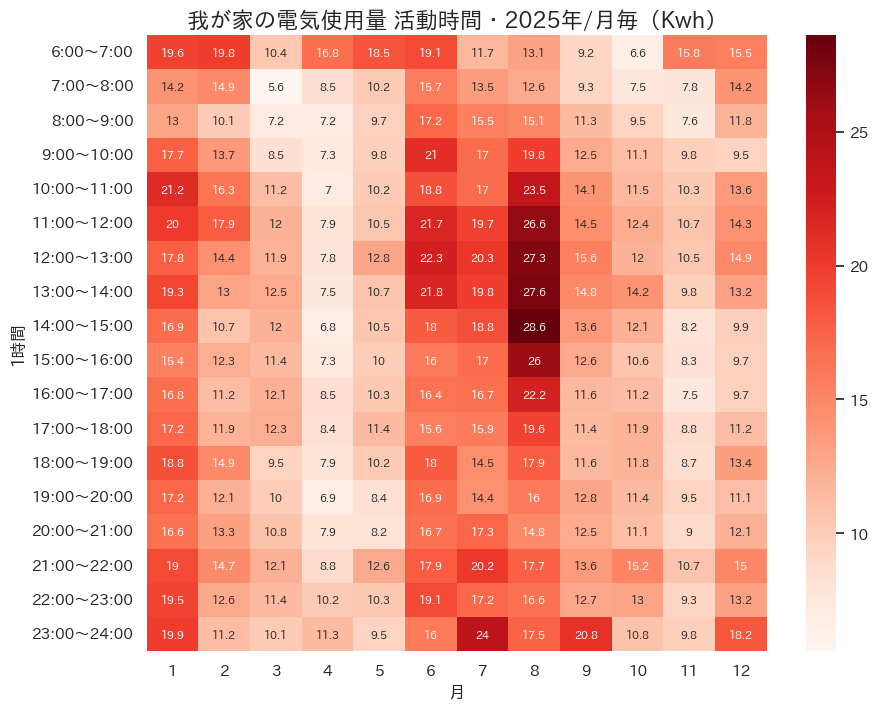

In [45]:
denki = pd.read_csv('denki.csv',
                    usecols=[0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], 
                 index_col=0,   
                 parse_dates=True) 
denki = denki.resample('1ME').sum()
denki['year'] = denki.index.year
denki['month'] = denki.index.month
denki_month = denki.groupby(['month','year'], as_index=False).sum()
denki2025 = denki_month[denki_month['year'] == 2025].drop(columns='year')
denki2025 = denki2025.set_index('month')

denki2025 = denki2025.iloc[:, 6:]#起きてるだろう時間帯だけ

denki2025_t2 = denki2025.T
denki2025_t2

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki2025_t2, annot=True, fmt='g', cmap='Reds',  annot_kws={'size':8})
plt.title('我が家の電気使用量 活動時間・2025年/月毎（Kwh）', fontsize=16)
plt.ylabel('1時間')
plt.xlabel('月')

Text(0.5, 1.0, '我が家の電気料金 24時間・2025年/月毎（¥）')

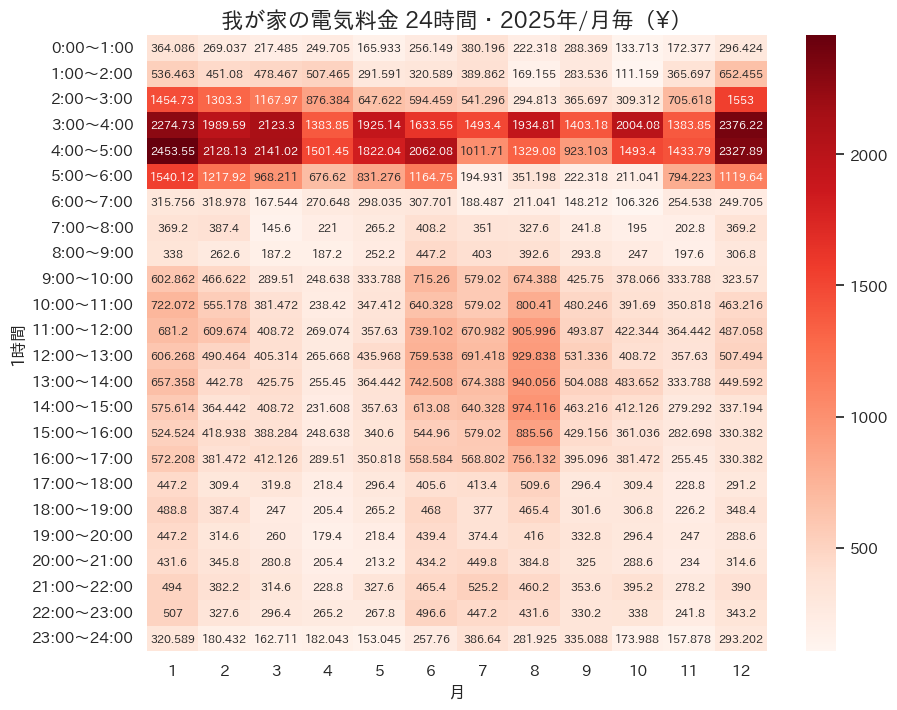

In [40]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2

denki['year'] = denki.index.year
denki['month'] = denki.index.month
denki_month = denki.groupby(['month','year'], as_index=False).sum()
denki2025 = denki_month[denki_month['year'] == 2025].drop(columns='year')
denki2025 = denki2025.set_index('month')

denki2025_t3 = denki2025.T
denki2025_t3

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki2025_t3, annot=True, fmt='g', cmap='Reds',  annot_kws={'size':8})
plt.ylabel('1時間')
plt.xlabel('月')
plt.title('我が家の電気料金 24時間・2025年/月毎（¥）', fontsize=16)

Text(0.5, 55.249999999999986, '月')

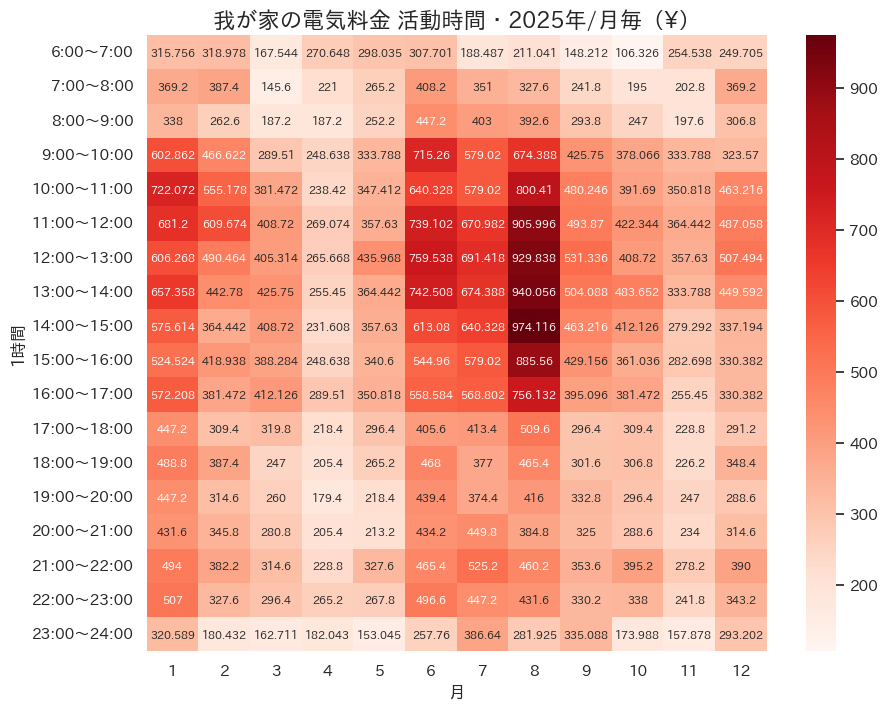

In [38]:
cols = [0] + list(range(2,26))
night_fee1 = 16.22 #電気料金2310-2403　夜間
day_fee1 = 34.21 #電気料金2310-2403　昼間
home_fee1 = 26.15 #電気料金2310-2403　ホーム
night_fee2 = 16.11 #電気料金2404-　夜間
day_fee2 = 34.06 #電気料金2404-　昼間
home_fee2 = 26.00 #電気料金2404-　ホーム

denki = pd.read_csv('denki.csv',
                    usecols=cols, 
                    index_col=0,   
                    parse_dates=True)

denki = denki.resample('1ME').sum()
denki.index = denki.index.to_period('M')

fee1_rows = list(range(0,6)) #2310-2403
fee2_rows = list(range(6, len(denki))) #2404-

night_cols = list(range(0, 7)) + [23] #[23:00-7:00]
day_cols = list(range(9,17)) #[9:00-17:00]
home_cols = list(range(7,9)) + list(range(17,23)) #[7:00-9:00]+[17:00-23:00]

denki.iloc[fee1_rows , night_cols] *= night_fee1
denki.iloc[fee1_rows , day_cols] *= day_fee1
denki.iloc[fee1_rows , home_cols] *= home_fee1

denki.iloc[fee2_rows , night_cols] *= night_fee2
denki.iloc[fee2_rows , day_cols] *= day_fee2
denki.iloc[fee2_rows , home_cols] *= home_fee2

denki['year'] = denki.index.year
denki['month'] = denki.index.month
denki_month = denki.groupby(['month','year'], as_index=False).sum()
denki2025 = denki_month[denki_month['year'] == 2025].drop(columns='year')
denki2025 = denki2025.set_index('month')

denki2025 = denki2025.iloc[:, 6:]#起きてるだろう時間帯だけ

denki2025_t4 = denki2025.T
denki2025_t4

plt.figure(figsize=(10, 8))
seaborn.heatmap(denki2025_t4, annot=True, fmt='g', cmap='Reds',  annot_kws={'size':8})
plt.title('我が家の電気料金 活動時間・2025年/月毎（¥）', fontsize=16)
plt.ylabel('1時間')
plt.xlabel('月')